# Analysis of Hindi Fluency and Semantic Arrangement

This notebook analyzes data from a Hindi Verbal Fluency Task (VFT) and Spatial Arrangement Map (SpAM) study. It extracts word sequences, inter-response times (IRTs), and spatial positions, and performs statistical tests and visualizations that are suitable for inclusion in a report or slide deck.

In [1]:
# Common imports and helper utilities

import json
import os
import urllib.request
from collections import Counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.cluster import KMeans
from scipy import stats

# optional utilities
try:
    from adjustText import adjust_text
except Exception:
    adjust_text = None  # adjust_text is optional; label placement will work without it

warnings.filterwarnings('ignore')

# Helper functions

def safe_load_list(x):
    """Parse fields that may be JSON-encoded lists or already lists."""
    if x is None:
        return []
    if isinstance(x, list):
        return x
    x = str(x).strip()
    if x == "" or x == "null":
        return []
    try:
        return json.loads(x)
    except Exception:
        return []


def is_devanagari(text):
    """Return True if the string contains Devanagari characters."""
    if not isinstance(text, str):
        return False
    return any('\u0900' <= ch <= '\u097F' for ch in text)


## Plotting configuration (centralized)

This cell provides a single place to control plotting appearance used throughout the notebook. Put all figure sizes, colour choices, default DPI, and commonly used font sizes here so figures are consistent across slides and the report.

How to use:
- Reference `COLORS` or `PALETTE` for domain-specific colours.
- Use `FIGSIZE_DEFAULT` or `FIGSIZE_LARGE` when creating figures (e.g., `plt.figure(figsize=FIGSIZE_LARGE)`).
- Call `save_fig('name.png')` to save images using the notebook's standard DPI and layout options.


In [2]:
# Font setup (uses matplotlib.font_manager already imported above)
font_path = "NotoSansDevanagari-Regular.ttf"
if not os.path.exists(font_path):
    try:
        url = "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf"
        print("Downloading Devanagari font...")
        urllib.request.urlretrieve(url, font_path)
        print("Font downloaded.")
    except Exception:
        print("Could not download font automatically; please place NotoSansDevanagari-Regular.ttf in the notebook folder.")

hindi_font = fm.FontProperties(fname=font_path)
hindi_font_small = fm.FontProperties(fname=font_path, size=9)
hindi_font_title = fm.FontProperties(fname=font_path, size=11)


# Dataset and purpose

Dataset: participant responses from a Hindi VFT and SpAM study (file: `hindi.json`). This section inspects the data structure and extracts per-participant trials to support the analyses presented below.

In [3]:
with open('hindi.json') as f:
    data = json.load(f)

print("Top-level keys:", list(data.keys()))

experiments = data['fluency-spam']

print("Number of participants:", len(experiments))
print("Participant IDs:", list(experiments.keys())[:5], "...")  # first 5 only


Top-level keys: ['fluency-spam']
Number of participants: 35
Participant IDs: ['1qmxoH7jT7VECeLUVEKU', '2kupFqWyVgUTsqisMsI7', '32zXoOEyomBdbyGIOg7U', '3zIUF3kkspNbB0QxKfOy', '7fxWA2O6NjFEe7m2ElN6'] ...


## Participant Data & Trial Overview
Inspecting the data structure for a single participant to map out the trial sequence.

In [4]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

first_id = list(experiments.keys())[0]
first_participant = experiments[first_id]

print("First participant ID:", first_id)
print()
print("Keys inside this participant's data:", list(first_participant.keys()))
print()
print("Subject number:", first_participant['subject_id'])
print("Number of trials:", len(first_participant['data']))


First participant ID: 1qmxoH7jT7VECeLUVEKU

Keys inside this participant's data: ['subject_id', 'data', 'user_agent', 'url', 'created_at']

Subject number: 10255
Number of trials: 27


In [5]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

first_id = list(experiments.keys())[0]
first_participant = experiments[first_id]


trials = first_participant['data']

print("Here are all 27 trials:\n")
for i, trial in enumerate(trials):
    task   = trial.get('task', '---')        # VFT or SpAM (or blank)
    domain = trial.get('domain', '---')      # animals, foods, etc (or blank)
    ttype  = trial.get('typeoftrial', '---') # instructions, demographics, etc
    
    print(f"Trial {i:2d} | task: {task:8s} | domain: {domain:20s} | type: {ttype}")


Here are all 27 trials:

Trial  0 | task: ---      | domain: ---                  | type: ---
Trial  1 | task: ---      | domain: ---                  | type: instructions
Trial  2 | task: ---      | domain: ---                  | type: instructions
Trial  3 | task: VFT      | domain: furniture-practice   | type: ---
Trial  4 | task: ---      | domain: ---                  | type: instructions
Trial  5 | task: SpAM     | domain: furniture-practice   | type: ---
Trial  6 | task: ---      | domain: ---                  | type: instructions
Trial  7 | task: VFT      | domain: colours              | type: ---
Trial  8 | task: ---      | domain: ---                  | type: instructions
Trial  9 | task: SpAM     | domain: colours              | type: ---
Trial 10 | task: ---      | domain: ---                  | type: instructions
Trial 11 | task: VFT      | domain: animals              | type: ---
Trial 12 | task: ---      | domain: ---                  | type: instructions
Trial 13 | task

In [6]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']
first_id = list(experiments.keys())[0]
first_participant = experiments[first_id]
trials = first_participant['data']

animals_vft = trials[11]

print("Task:", animals_vft.get('task'))
print("Domain:", animals_vft.get('domain'))
print()

# The words typed are stored as a string, we need to convert it to a list
words_raw = animals_vft.get('tagged_responses')
times_raw = animals_vft.get('response_times')

words = json.loads(words_raw)   # converts the string into a Python list
times = json.loads(times_raw)

print("Words typed (in order):")
for i, (word, time) in enumerate(zip(words, times)):
    print(f"  Word {i+1:2d}: {word['response']:15s}  | time taken: {time/1000:.1f} seconds")


Task: VFT
Domain: animals

Words typed (in order):
  Word  1: lion             | time taken: 3.1 seconds
  Word  2: tiger            | time taken: 2.0 seconds
  Word  3: girrafe          | time taken: 2.7 seconds
  Word  4: leapord          | time taken: 3.3 seconds
  Word  5: dolhin           | time taken: 2.3 seconds
  Word  6: whale            | time taken: 1.8 seconds
  Word  7: shark            | time taken: 2.1 seconds
  Word  8: crcocdile        | time taken: 2.9 seconds
  Word  9: saprrow          | time taken: 2.7 seconds
  Word 10: crow             | time taken: 1.4 seconds
  Word 11: parrot           | time taken: 3.2 seconds
  Word 12: peigien          | time taken: 2.5 seconds
  Word 13: owl              | time taken: 0.9 seconds
  Word 14: eagle            | time taken: 2.0 seconds
  Word 15: cow              | time taken: 1.0 seconds
  Word 16: buffaloe         | time taken: 2.7 seconds
  Word 17: goat             | time taken: 1.8 seconds
  Word 18: sheep            | t

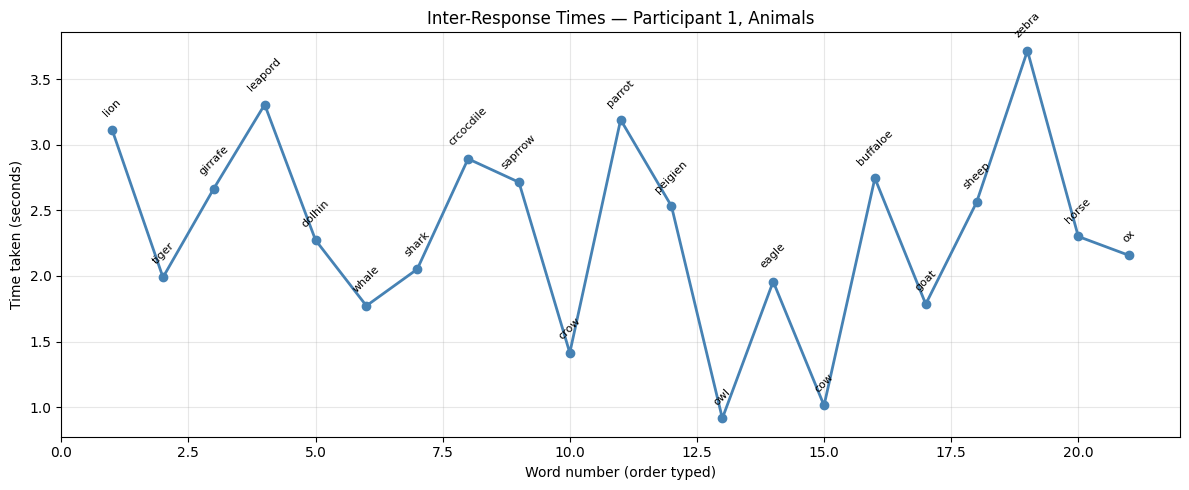

Plot saved as irt_plot.png


In [7]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']
first_id = list(experiments.keys())[0]
first_participant = experiments[first_id]
trials = first_participant['data']

animals_vft = trials[11]
words = json.loads(animals_vft.get('tagged_responses'))
times = json.loads(animals_vft.get('response_times'))

word_labels = [w['response'] for w in words]
irts        = [t / 1000 for t in times]   # convert ms to seconds

plt.figure(figsize=(12, 5))

plt.plot(range(1, len(irts)+1), irts, marker='o', color='steelblue', linewidth=2)

# Label each point with the word
for i, (word, irt) in enumerate(zip(word_labels, irts)):
    plt.text(i+1, irt + 0.1, word, fontsize=8, ha='center', rotation=45)

plt.xlabel('Word number (order typed)')
plt.ylabel('Time taken (seconds)')
plt.title('Inter-Response Times — Participant 1, Animals')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('irt_plot.png')
plt.show()
print("Plot saved as irt_plot.png")


In [8]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']
first_id = list(experiments.keys())[0]
first_participant = experiments[first_id]
trials = first_participant['data']

animals_spam = trials[13]

print("Task:", animals_spam.get('task'))
print("Domain:", animals_spam.get('domain'))
print()

dropped_words = animals_spam.get('droppedwords')

print("Word positions on the screen:\n")
print(f"{'Word':15s} | {'X position':12s} | {'Y position'}")
print("-" * 45)

for item in dropped_words:
    word = item['word']
    x    = item['x_norm']   # normalised x (0 = left edge, 1 = right edge)
    y    = item['y_norm']   # normalised y (0 = top edge, 1 = bottom edge)
    print(f"{word:15s} | {x:.3f}        | {y:.3f}")


Task: SpAM
Domain: animals

Word positions on the screen:

Word            | X position   | Y position
---------------------------------------------
lion            | 0.026        | 1.004
tiger           | 0.069        | 1.001
girrafe         | 0.034        | 0.699
leapord         | 0.122        | 1.004
dolhin          | 1.001        | 0.003
whale           | 1.001        | 0.184
whale           | 1.000        | 0.116
shark           | 1.001        | 0.221
crcocdile       | 0.840        | 0.337
saprrow         | 0.278        | 0.003
crow            | 0.286        | 0.087
parrot          | 0.282        | 0.176
peigien         | 0.278        | 0.254
owl             | 0.284        | 0.335
eagle           | 0.354        | 0.004
crow            | 0.428        | 0.003
parrot          | 0.298        | 0.050
peigien         | 0.363        | 0.050
owl             | 0.413        | 0.079
cow             | 0.301        | 0.473
buffaloe        | 0.291        | 0.385
goat            | 0.299        |

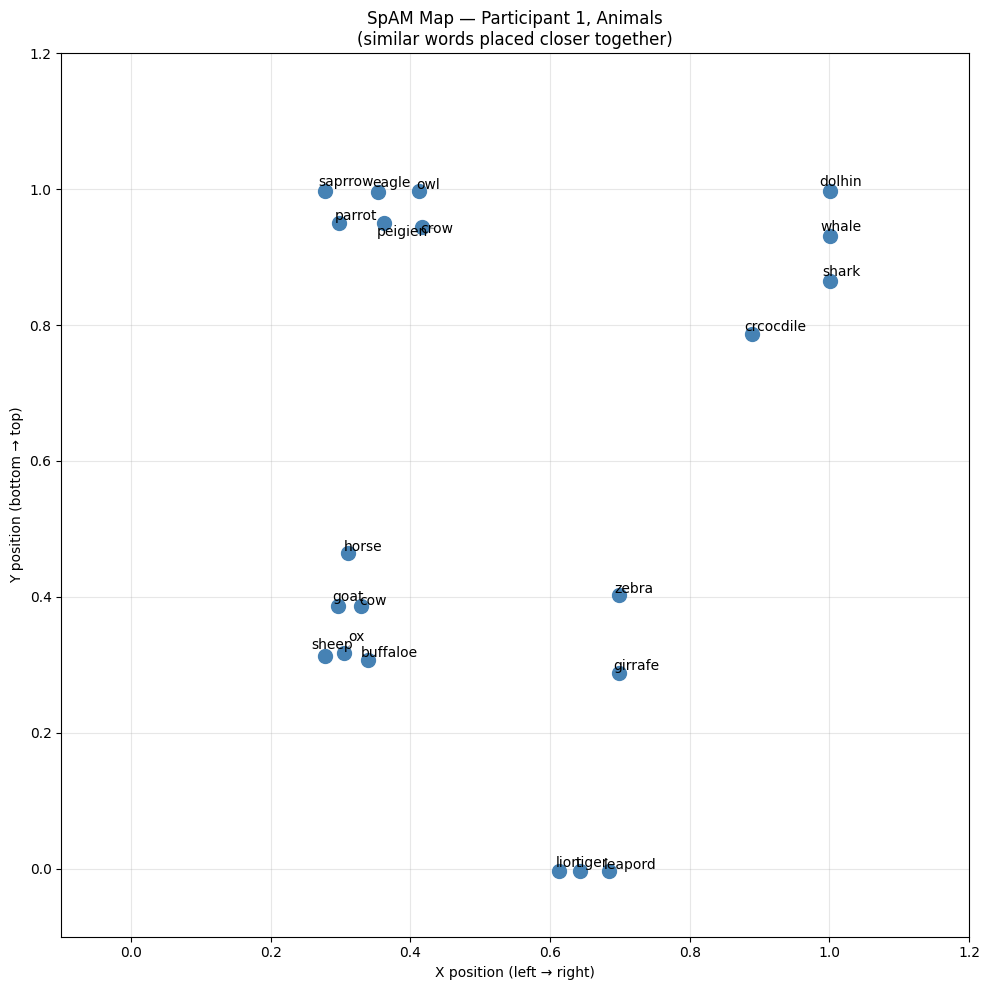

Saved!


In [9]:
animals_spam = None
with open('hindi.json') as f:
    data = json.load(f)
    experiments = data['fluency-spam']
    first_id = list(experiments.keys())[0]
    first_participant = experiments[first_id]
    trials = first_participant['data']
    animals_spam = trials[13]

# SpAM: keep only last position of each word
final_positions = {}
for item in animals_spam.get('droppedwords', []):
    word = item['word']
    x    = item['x_norm']
    y    = item['y_norm']
    final_positions[word] = (x, y)

plt.figure(figsize=(10, 10))

xs, ys, labels = [], [], []

for word, (x, y) in final_positions.items():
    flipped_y = 1 - y          # flip so top of screen = top of graph
    xs.append(x)
    ys.append(flipped_y)
    labels.append(word)
    plt.scatter(x, flipped_y, s=100, color='steelblue', zorder=2)

# adjustText automatically moves labels so they don't overlap (if available)
texts = [plt.text(xs[i], ys[i], labels[i], fontsize=10) for i in range(len(labels))]
if adjust_text is not None:
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))

plt.xlim(-0.1, 1.2)
plt.ylim(-0.1, 1.2)
plt.xlabel('X position (left → right)')
plt.ylabel('Y position (bottom → top)')
plt.title('SpAM Map — Participant 1, Animals\n(similar words placed closer together)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('spam_map.png', dpi=150)
plt.show()
print("Saved!")


In [10]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

all_vft_data  = []   # for word + IRT data
all_spam_data = []   # for x,y position data

# loop over every participant 
for participant_id, participant in experiments.items():

    trials = participant['data']

    for trial in trials:

        task   = trial.get('task')
        domain = trial.get('domain')

        # skip practice trial and skip non-task trials
        if domain == 'furniture-practice':
            continue
        if task not in ('VFT', 'SpAM'):
            continue

        # collect VFT data
        if task == 'VFT':
            words_raw = trial.get('tagged_responses', '[]')
            times_raw = trial.get('response_times',   '[]')

            words = [w['response'].strip() for w in json.loads(words_raw)]
            irts  = [t / 1000 for t in json.loads(times_raw)]  # ms to seconds

            all_vft_data.append({
                'participant': participant_id,
                'domain':      domain,
                'words':       words,
                'irts':        irts
            })

        # collect SpAM data
        if task == 'SpAM':
            dropped = trial.get('droppedwords', [])

            # Keep only the LAST position of each word
            final_positions = {}
            for item in dropped:
                word = item['word']
                x    = item['x_norm']
                y    = item['y_norm']
                final_positions[word] = (x, y)

            all_spam_data.append({
                'participant': participant_id,
                'domain':      domain,
                'positions':   final_positions
            })

# print a summary to check everything looks right
print(f"Total VFT entries collected:  {len(all_vft_data)}")
print(f"Total SpAM entries collected: {len(all_spam_data)}")
print()

# Show a breakdown by domain
vft_domains  = Counter(entry['domain'] for entry in all_vft_data)
spam_domains = Counter(entry['domain'] for entry in all_spam_data)

print("VFT entries per domain:")
for domain, count in sorted(vft_domains.items()):
    print(f"  {domain:15s} → {count} participants")

print()
print("SpAM entries per domain:")
for domain, count in sorted(spam_domains.items()):
    print(f"  {domain:15s} → {count} participants")

print()
# check at the first entry to make sure it looks right
print("First VFT entry:")
first = all_vft_data[0]
print(f"  Participant: {first['participant']}")
print(f"  Domain:      {first['domain']}")
print(f"  Words:       {first['words']}")
print(f"  IRTs:        {[round(t,1) for t in first['irts']]}")


Total VFT entries collected:  105
Total SpAM entries collected: 105

VFT entries per domain:
  animals         → 35 participants
  body-parts      → 24 participants
  colours         → 11 participants
  foods           → 35 participants

SpAM entries per domain:
  animals         → 35 participants
  body-parts      → 24 participants
  colours         → 11 participants
  foods           → 35 participants

First VFT entry:
  Participant: 1qmxoH7jT7VECeLUVEKU
  Domain:      colours
  Words:       ['red', 'blue', 'green', 'indigo', 'orange', 'purple', 'white', 'black', 'pink', 'saffron', 'violet', 'silver', 'gray', 'brown']
  IRTs:        [2.6, 1.5, 1.5, 1.9, 1.6, 2.2, 8.2, 1.6, 3.5, 2.5, 3.1, 4.3, 7.9, 7.7]


In [11]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

all_vft_data = []

for participant_id, participant in experiments.items():
    trials = participant['data']
    for trial in trials:
        task   = trial.get('task')
        domain = trial.get('domain')
        if domain == 'furniture-practice':
            continue
        if task != 'VFT':
            continue
        words_raw = trial.get('tagged_responses', '[]')
        times_raw = trial.get('response_times',   '[]')
        words = [w['response'].strip() for w in json.loads(words_raw)]
        irts  = [t / 1000 for t in json.loads(times_raw)]
        all_vft_data.append({
            'participant': participant_id,
            'domain':      domain,
            'words':       words,
            'irts':        irts
        })

# calculate statistics per domain
print("=" * 60)
print(f"{'Domain':15s} | {'N':4s} | {'Mean words':12s} | {'Mean IRT (s)'}")
print("=" * 60)

domains = ['animals', 'foods', 'body-parts', 'colours']

for domain in domains:

    # Get all entries for this domain
    entries = [e for e in all_vft_data if e['domain'] == domain]

    if not entries:
        continue

    # Word counts per participant
    word_counts = [len(e['words']) for e in entries]

    # All IRTs across all participants in this domain
    all_irts = [irt for e in entries for irt in e['irts']]

    n         = len(entries)
    mean_words = np.mean(word_counts)
    sd_words   = np.std(word_counts)
    mean_irt   = np.mean(all_irts)
    sd_irt     = np.std(all_irts)

    print(f"{domain:15s} | {n:4d} | {mean_words:.1f} (±{sd_words:.1f})  | {mean_irt:.2f} (±{sd_irt:.2f})")

print("=" * 60)
print()
print("What these numbers mean:")
print("  Mean words = average number of words typed per participant")
print("  Mean IRT   = average gap between words (in seconds)")
print("  ±          = standard deviation (spread around the mean)")


Domain          | N    | Mean words   | Mean IRT (s)
animals         |   35 | 10.4 (±4.5)  | 5.40 (±4.35)
foods           |   35 | 9.3 (±4.0)  | 6.05 (±5.25)
body-parts      |   24 | 8.6 (±3.0)  | 6.35 (±4.84)
colours         |   11 | 13.4 (±3.3)  | 3.93 (±2.93)

What these numbers mean:
  Mean words = average number of words typed per participant
  Mean IRT   = average gap between words (in seconds)
  ±          = standard deviation (spread around the mean)


Clusters found:

  Cluster 0: ['dolhin', 'whale', 'shark', 'crcocdile']
  Cluster 1: ['cow', 'buffaloe', 'goat', 'sheep', 'horse', 'ox']
  Cluster 2: ['lion', 'tiger', 'girrafe', 'leapord', 'zebra']
  Cluster 3: ['saprrow', 'crow', 'parrot', 'peigien', 'owl', 'eagle']


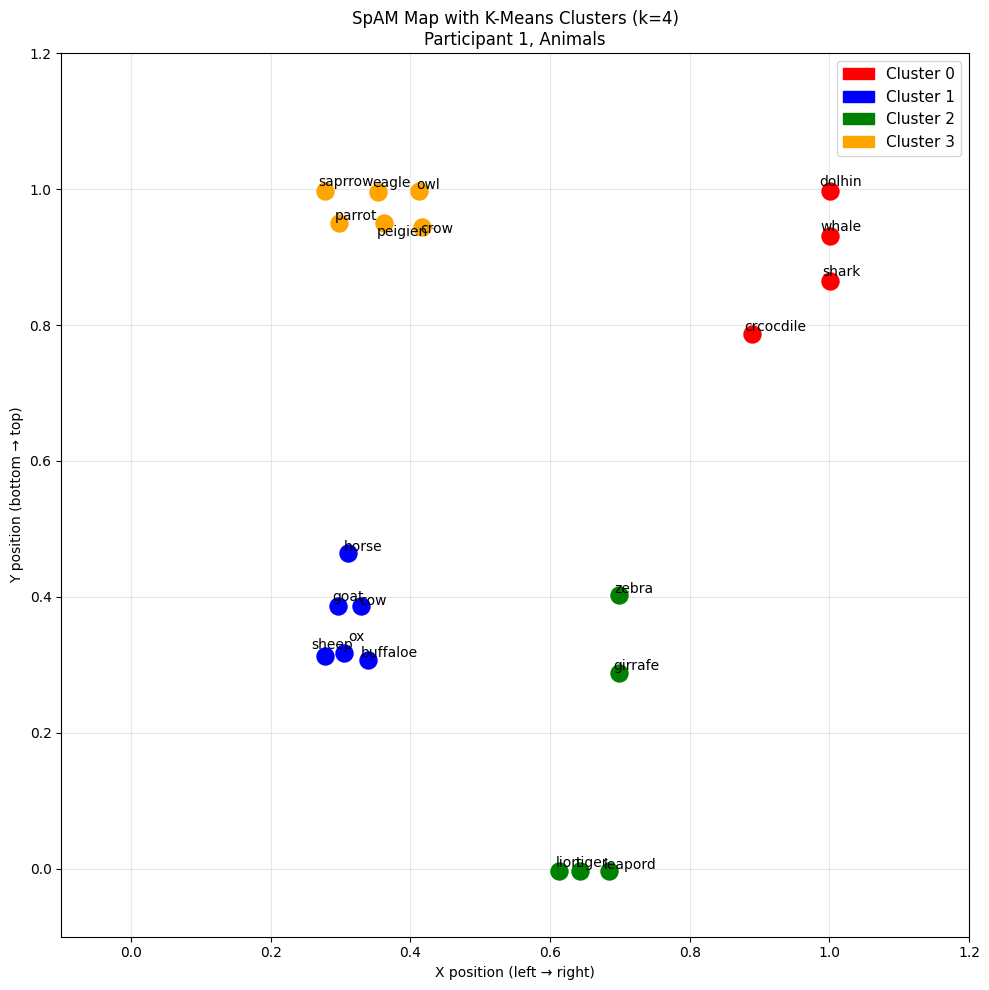


Saved as spam_clusters.png


In [12]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']
first_id    = list(experiments.keys())[0]
first_participant = experiments[first_id]
trials = first_participant['data']

# Get SpAM positions for animals (trial 13)
animals_spam = trials[13]
dropped      = animals_spam.get('droppedwords', [])

# Keep last position of each word
final_positions = {}
for item in dropped:
    final_positions[item['word']] = (item['x_norm'], item['y_norm'])

words = list(final_positions.keys())
coords = np.array(list(final_positions.values()))  # shape: (n_words, 2)

# Run k-means with k=4 clusters 
k = 4
kmeans  = KMeans(n_clusters=k, random_state=42, n_init=10)
labels  = kmeans.fit_predict(coords)   # assigns each word a cluster number (0,1,2,3)

# Print which words ended up in which cluster
print("Clusters found:\n")
colors = ['red', 'blue', 'green', 'orange', 'purple']

for cluster_num in range(k):
    words_in_cluster = [words[i] for i in range(len(words)) if labels[i] == cluster_num]
    print(f"  Cluster {cluster_num}: {words_in_cluster}")

# Plot the SpAM map with clusters coloured 
plt.figure(figsize=(10, 10))

texts = []
for i, (word, (x, y)) in enumerate(final_positions.items()):
    cluster_color = colors[labels[i]]
    plt.scatter(x, 1-y, s=150, color=cluster_color, zorder=2)
    texts.append(plt.text(x, 1-y, word, fontsize=10))

if adjust_text is not None:
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))

# Add a legend
from matplotlib.patches import Patch
legend = [Patch(color=colors[i], label=f'Cluster {i}') for i in range(k)]
plt.legend(handles=legend, fontsize=11)

plt.xlim(-0.1, 1.2)
plt.ylim(-0.1, 1.2)
plt.xlabel('X position (left → right)')
plt.ylabel('Y position (bottom → top)')
plt.title(f'SpAM Map with K-Means Clusters (k={k})\nParticipant 1, Animals')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('spam_clusters.png', dpi=150)
plt.show()
print("\nSaved as spam_clusters.png")


In [13]:
with open('hindi.json') as f:
    data = json.load(f)

experiments  = data['fluency-spam']
first_id     = list(experiments.keys())[0]
first_participant = experiments[first_id]
trials       = first_participant['data']

# Get SpAM clusters (trial 13)
animals_spam = trials[13]
dropped      = animals_spam.get('droppedwords', [])

final_positions = {}
for item in dropped:
    final_positions[item['word']] = (item['x_norm'], item['y_norm'])

words_spam = list(final_positions.keys())
coords     = np.array(list(final_positions.values()))

k      = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(coords)

# Make a dictionary: word to cluster number
word_to_cluster = {words_spam[i]: labels[i] for i in range(len(words_spam))}

print("Word → Cluster mapping:")
for word, cluster in word_to_cluster.items():
    print(f"  {word:15s} → Cluster {cluster}")

# Get VFT word sequence + IRTs (trial 11)
animals_vft = trials[11]
words_raw   = animals_vft.get('tagged_responses', '[]')
times_raw   = animals_vft.get('response_times',   '[]')

vft_words = [w['response'].strip() for w in json.loads(words_raw)]
irts      = [t / 1000 for t in json.loads(times_raw)]

# Compare consecutive pairs
within_cluster_irts  = []
between_cluster_irts = []

print("\nConsecutive word pairs:\n")
print(f"{'Word 1':15s} → {'Word 2':15s} | {'IRT':6s} | {'Same cluster?'}")
print("-" * 60)

for i in range(len(vft_words) - 1):
    word1 = vft_words[i]
    word2 = vft_words[i + 1]
    irt   = irts[i + 1]   # IRT before word2

    # Only compare if BOTH words exist in SpAM data
    if word1 not in word_to_cluster or word2 not in word_to_cluster:
        print(f"  {word1:15s} → {word2:15s} | {irt:.2f}s | (skipped — word not in SpAM)")
        continue

    cluster1 = word_to_cluster[word1]
    cluster2 = word_to_cluster[word2]

    same = cluster1 == cluster2

    if same:
        within_cluster_irts.append(irt)
        label = "YES ← within cluster"
    else:
        between_cluster_irts.append(irt)
        label = "no  (cluster switch)"

    print(f"  {word1:15s} → {word2:15s} | {irt:.2f}s | {label}")

# Print the summary
print("\n" + "=" * 50)
print("RESULTS:")
print(f"  Within-cluster  IRTs: n={len(within_cluster_irts):2d}, mean={np.mean(within_cluster_irts):.2f}s")
print(f"  Between-cluster IRTs: n={len(between_cluster_irts):2d}, mean={np.mean(between_cluster_irts):.2f}s")
print()
print("  If H1 is correct, within-cluster mean should be LOWER")
print("  than between-cluster mean.")


Word → Cluster mapping:
  lion            → Cluster 2
  tiger           → Cluster 2
  girrafe         → Cluster 2
  leapord         → Cluster 2
  dolhin          → Cluster 0
  whale           → Cluster 0
  shark           → Cluster 0
  crcocdile       → Cluster 0
  saprrow         → Cluster 3
  crow            → Cluster 3
  parrot          → Cluster 3
  peigien         → Cluster 3
  owl             → Cluster 3
  eagle           → Cluster 3
  cow             → Cluster 1
  buffaloe        → Cluster 1
  goat            → Cluster 1
  sheep           → Cluster 1
  zebra           → Cluster 2
  horse           → Cluster 1
  ox              → Cluster 1

Consecutive word pairs:

Word 1          → Word 2          | IRT    | Same cluster?
------------------------------------------------------------
  lion            → tiger           | 1.99s | YES ← within cluster
  tiger           → girrafe         | 2.67s | YES ← within cluster
  girrafe         → leapord         | 3.31s | YES ← within cluster

In [14]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

# We'll collect within and between IRTs across ALL participants
all_within  = []
all_between = []

skipped = 0

for participant_id, participant in experiments.items():
    trials = participant['data']

    # Find the animals VFT and SpAM trials for this participant
    vft_trial  = None
    spam_trial = None

    for trial in trials:
        task   = trial.get('task')
        domain = trial.get('domain')
        if domain == 'animals' and task == 'VFT':
            vft_trial = trial
        if domain == 'animals' and task == 'SpAM':
            spam_trial = trial

    # Skip if either trial is missing
    if vft_trial is None or spam_trial is None:
        skipped += 1
        continue

    # Get SpAM clusters
    dropped = spam_trial.get('droppedwords', [])
    final_positions = {}
    for item in dropped:
        final_positions[item['word']] = (item['x_norm'], item['y_norm'])

    if len(final_positions) < 4:   # need at least 4 words to cluster
        skipped += 1
        continue

    words_spam = list(final_positions.keys())
    coords     = np.array(list(final_positions.values()))

    # Choose k — use 4 or number of words divided by 3, whichever is smaller
    k = min(4, len(words_spam) // 3)
    if k < 2:
        skipped += 1
        continue

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(coords)
    word_to_cluster = {words_spam[i]: labels[i] for i in range(len(words_spam))}

    # Get VFT sequence
    words_raw = vft_trial.get('tagged_responses', '[]')
    times_raw = vft_trial.get('response_times',   '[]')
    vft_words = [w['response'].strip() for w in json.loads(words_raw)]
    irts      = [t / 1000 for t in json.loads(times_raw)]

    # Compare consecutive pairs
    for i in range(len(vft_words) - 1):
        word1 = vft_words[i]
        word2 = vft_words[i + 1]
        irt   = irts[i + 1]

        if word1 not in word_to_cluster or word2 not in word_to_cluster:
            continue

        if word_to_cluster[word1] == word_to_cluster[word2]:
            all_within.append(irt)
        else:
            all_between.append(irt)

# Print results
print("=" * 55)
print("H1 TEST — Animals domain, all participants")
print("=" * 55)
print(f"  Within-cluster  pairs: n={len(all_within):3d}, mean={np.mean(all_within):.2f}s (±{np.std(all_within):.2f})")
print(f"  Between-cluster pairs: n={len(all_between):3d}, mean={np.mean(all_between):.2f}s (±{np.std(all_between):.2f})")
print()

# Run the t-test
t_stat, p_value = stats.ttest_ind(all_within, all_between)

print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value:     {p_value:.4f}")
print()

if p_value < 0.05:
    print("  ✓ Result is SIGNIFICANT (p < 0.05)")
    print("  Within-cluster IRTs are reliably shorter than between-cluster IRTs")
    print("  → H1 is SUPPORTED for animals!")
else:
    print("  ✗ Result is NOT significant (p >= 0.05)")
    print("  → H1 is not supported for animals")

print()
print(f"  (Skipped {skipped} participants due to insufficient data)")


H1 TEST — Animals domain, all participants
  Within-cluster  pairs: n=165, mean=4.24s (±2.67)
  Between-cluster pairs: n=136, mean=5.32s (±4.02)

  t-statistic: -2.771
  p-value:     0.0059

  ✓ Result is SIGNIFICANT (p < 0.05)
  Within-cluster IRTs are reliably shorter than between-cluster IRTs
  → H1 is SUPPORTED for animals!

  (Skipped 3 participants due to insufficient data)


In [15]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

domains = ['animals', 'foods', 'body-parts', 'colours']

print("=" * 65)
print("H1 TEST — All domains")
print("=" * 65)

results = {}   # we'll store results here for the presentation

for domain in domains:

    all_within  = []
    all_between = []
    skipped     = 0

    for participant_id, participant in experiments.items():
        trials = participant['data']

        vft_trial  = None
        spam_trial = None

        for trial in trials:
            task   = trial.get('task')
            dom    = trial.get('domain')
            if dom == domain and task == 'VFT':
                vft_trial = trial
            if dom == domain and task == 'SpAM':
                spam_trial = trial

        if vft_trial is None or spam_trial is None:
            skipped += 1
            continue

        #  SpAM clusters 
        dropped = spam_trial.get('droppedwords', [])
        final_positions = {}
        for item in dropped:
            final_positions[item['word']] = (item['x_norm'], item['y_norm'])

        if len(final_positions) < 4:
            skipped += 1
            continue

        words_spam = list(final_positions.keys())
        coords     = np.array(list(final_positions.values()))

        k = min(4, len(words_spam) // 3)
        if k < 2:
            skipped += 1
            continue

        kmeans          = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels          = kmeans.fit_predict(coords)
        word_to_cluster = {words_spam[i]: labels[i] for i in range(len(words_spam))}

        #  VFT sequence 
        words_raw = vft_trial.get('tagged_responses', '[]')
        times_raw = vft_trial.get('response_times',   '[]')
        vft_words = [w['response'].strip() for w in json.loads(words_raw)]
        irts      = [t / 1000 for t in json.loads(times_raw)]

        for i in range(len(vft_words) - 1):
            word1 = vft_words[i]
            word2 = vft_words[i + 1]
            irt   = irts[i + 1]

            if word1 not in word_to_cluster or word2 not in word_to_cluster:
                continue

            if word_to_cluster[word1] == word_to_cluster[word2]:
                all_within.append(irt)
            else:
                all_between.append(irt)

    #  Run t-test 
    if len(all_within) < 2 or len(all_between) < 2:
        print(f"\n{domain}: not enough data")
        continue

    t_stat, p_value = stats.ttest_ind(all_within, all_between)

    # Bonferroni corrected threshold (12 tests total)
    corrected_threshold = 0.05 / 12

    results[domain] = {
        'within_mean':  np.mean(all_within),
        'between_mean': np.mean(all_between),
        'within_n':     len(all_within),
        'between_n':    len(all_between),
        't_stat':       t_stat,
        'p_value':      p_value,
        'significant':  p_value < 0.05,
        'sig_bonferroni': p_value < corrected_threshold,
    }

    print(f"\nDomain: {domain.upper()}")
    print(f"  Within-cluster  : n={len(all_within):3d}, mean={np.mean(all_within):.2f}s")
    print(f"  Between-cluster : n={len(all_between):3d}, mean={np.mean(all_between):.2f}s")
    print(f"  Difference      : {np.mean(all_between) - np.mean(all_within):.2f}s")
    print(f"  t = {t_stat:.3f}, p = {p_value:.4f}")

    if p_value < corrected_threshold:
        print(f"  ✓ SIGNIFICANT after Bonferroni correction (p < {corrected_threshold:.4f})")
    elif p_value < 0.05:
        print(f"  ~ Significant at p<0.05 but NOT after Bonferroni correction")
    else:
        print(f"  ✗ Not significant")

    print(f"  (skipped {skipped} participants)")

print("\n" + "=" * 65)
print("SUMMARY TABLE")
print("=" * 65)
print(f"{'Domain':12s} | {'Within':8s} | {'Between':8s} | {'Diff':6s} | {'p-value':8s} | {'Significant?'}")
print("-" * 70)
for domain, r in results.items():
    diff = r['between_mean'] - r['within_mean']
    sig  = "✓ YES" if r['sig_bonferroni'] else ("~ borderline" if r['significant'] else "✗ NO")
    print(f"{domain:12s} | {r['within_mean']:.2f}s    | {r['between_mean']:.2f}s    | {diff:.2f}s  | {r['p_value']:.4f}   | {sig}")


H1 TEST — All domains

Domain: ANIMALS
  Within-cluster  : n=165, mean=4.24s
  Between-cluster : n=136, mean=5.32s
  Difference      : 1.08s
  t = -2.771, p = 0.0059
  ~ Significant at p<0.05 but NOT after Bonferroni correction
  (skipped 3 participants)

Domain: FOODS
  Within-cluster  : n=148, mean=4.26s
  Between-cluster : n=122, mean=5.38s
  Difference      : 1.11s
  t = -2.709, p = 0.0072
  ~ Significant at p<0.05 but NOT after Bonferroni correction
  (skipped 2 participants)

Domain: BODY-PARTS
  Within-cluster  : n= 81, mean=5.57s
  Between-cluster : n= 76, mean=5.24s
  Difference      : -0.33s
  t = 0.658, p = 0.5118
  ✗ Not significant
  (skipped 14 participants)

Domain: COLOURS
  Within-cluster  : n= 47, mean=3.26s
  Between-cluster : n= 89, mean=3.97s
  Difference      : 0.71s
  t = -1.380, p = 0.1700
  ✗ Not significant
  (skipped 24 participants)

SUMMARY TABLE
Domain       | Within   | Between  | Diff   | p-value  | Significant?
------------------------------------------

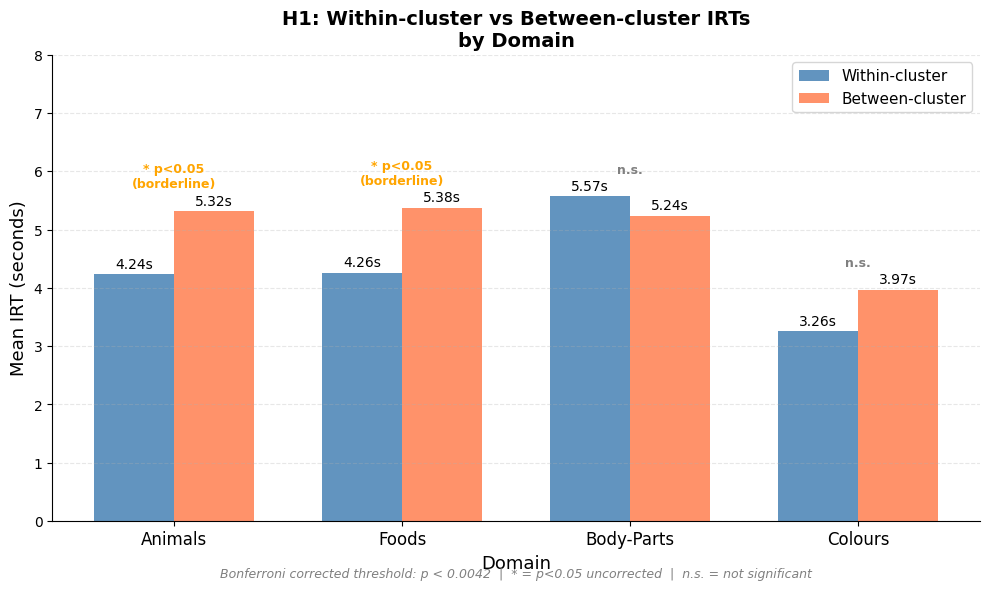

Saved as h1_bar_chart.png


In [16]:
#  Bar chart summarising H1 results (values can be updated from analysis cells)
domains      = ['Animals', 'Foods', 'Body-Parts', 'Colours']
within_means = [4.24,      4.26,    5.57,         3.26]
between_means= [5.32,      5.38,    5.24,         3.97]
p_values     = [0.0059,    0.0072,  0.5118,       0.1700]

x     = np.arange(len(domains))   # [0, 1, 2, 3]
width = 0.35                       # width of each bar

fig, ax = plt.subplots(figsize=(10, 6))

# Draw the bars
bars_within  = ax.bar(x - width/2, within_means,  width,
                      label='Within-cluster',  color='steelblue',  alpha=0.85)
bars_between = ax.bar(x + width/2, between_means, width,
                      label='Between-cluster', color='coral', alpha=0.85)

# Add numbers on top of each bar
for bar in bars_within:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{bar.get_height():.2f}s',
            ha='center', va='bottom', fontsize=10)

for bar in bars_between:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{bar.get_height():.2f}s',
            ha='center', va='bottom', fontsize=10)

# Add significance labels above each pair
bonferroni = 0.0042
for i, p in enumerate(p_values):
    top = max(within_means[i], between_means[i]) + 0.35
    if p < bonferroni:
        label = '** p<0.0042'
        color = 'green'
    elif p < 0.05:
        label = '* p<0.05\n(borderline)'
        color = 'orange'
    else:
        label = 'n.s.'
        color = 'gray'
    ax.text(i, top, label, ha='center', va='bottom', fontsize=9, color=color, fontweight='bold')

# Labels and formatting
ax.set_xlabel('Domain', fontsize=13)
ax.set_ylabel('Mean IRT (seconds)', fontsize=13)
ax.set_title('H1: Within-cluster vs Between-cluster IRTs\nby Domain', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(domains, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 8)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(0.5, -0.12,
        'Bonferroni corrected threshold: p < 0.0042  |  * = p<0.05 uncorrected  |  n.s. = not significant',
        ha='center', transform=ax.transAxes,
        fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig('h1_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as h1_bar_chart.png")


In [17]:
# Verify Devanagari font is available for plotting
if os.path.exists(font_path):
    print(f"Using font: {font_path}")
else:
    print("Devanagari font not found. Some Hindi labels may not render correctly.")


Using font: NotoSansDevanagari-Regular.ttf


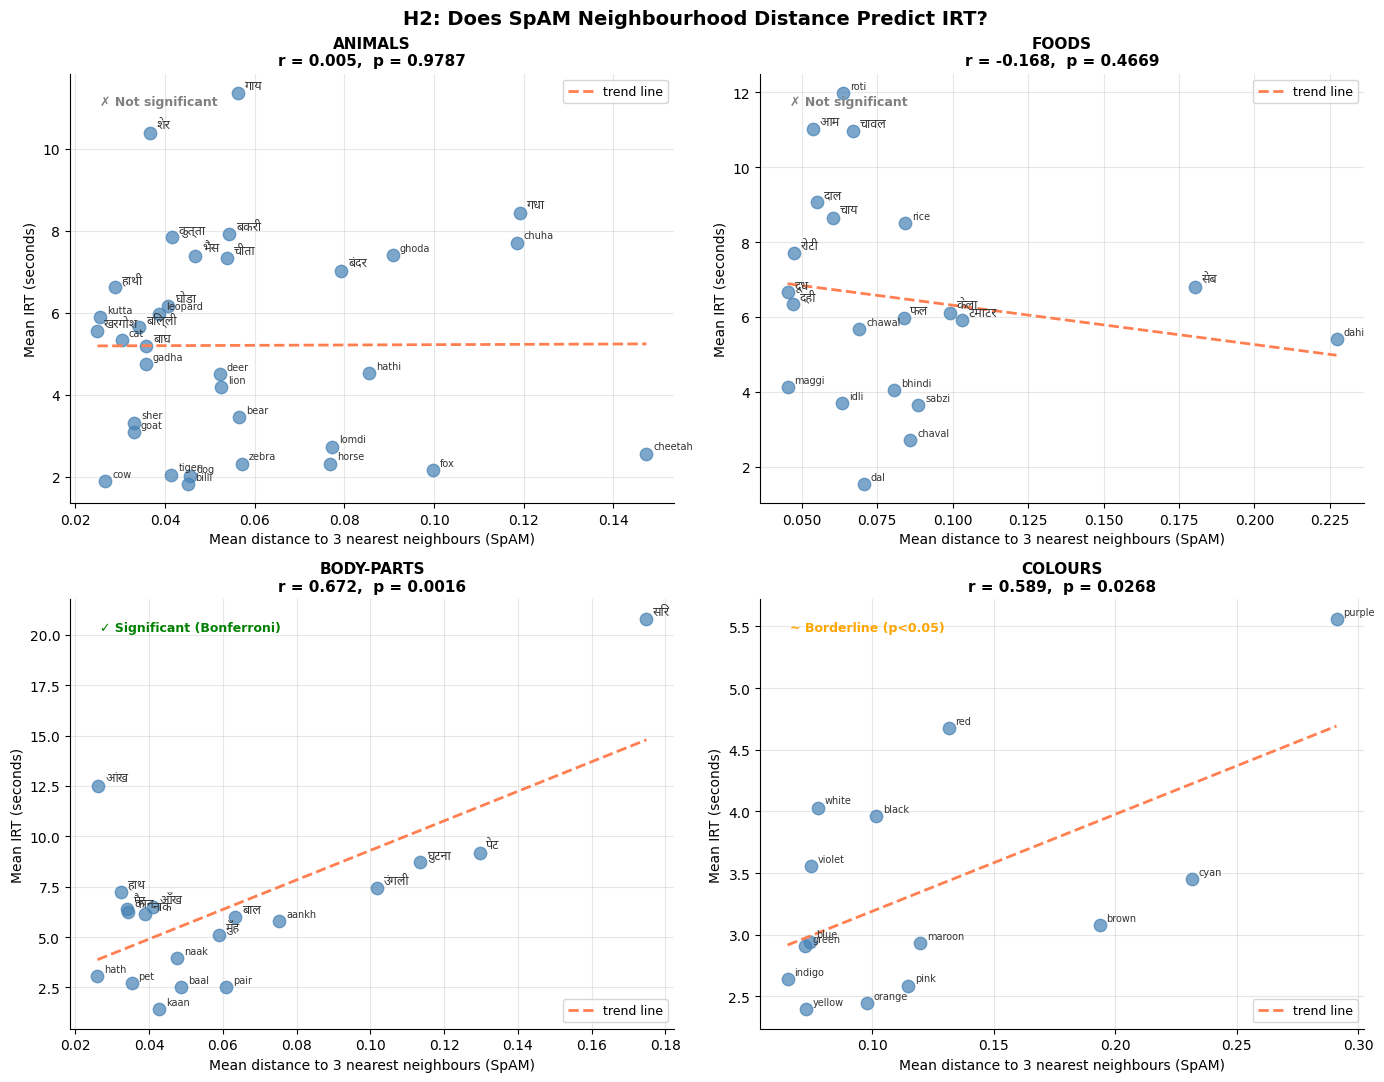

Saved as h2_scatter.png


In [18]:
# Scatter plots testing whether SpAM neighbourhood distance predicts IRT

with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']
domains     = ['animals', 'foods', 'body-parts', 'colours']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for idx, domain in enumerate(domains):

    # Collect SpAM positions
    word_positions = {}
    for participant_id, participant in experiments.items():
        for trial in participant['data']:
            if trial.get('task') == 'SpAM' and trial.get('domain') == domain:
                dropped = trial.get('droppedwords', [])
                final   = {}
                for item in dropped:
                    final[item['word']] = (item['x_norm'], item['y_norm'])
                for word, pos in final.items():
                    word_positions.setdefault(word, []).append(pos)

    # Collect mean IRTs
    word_irts = {}
    for participant_id, participant in experiments.items():
        for trial in participant['data']:
            if trial.get('task') == 'VFT' and trial.get('domain') == domain:
                words_raw = trial.get('tagged_responses', '[]')
                times_raw = trial.get('response_times',   '[]')
                words = [w['response'].strip() for w in json.loads(words_raw)]
                irts  = [t / 1000 for t in json.loads(times_raw)]
                for word, irt in zip(words, irts):
                    word_irts.setdefault(word, []).append(irt)

    # Find common words
    common_words = [w for w in word_positions
                    if w in word_irts
                    and len(word_positions[w]) >= 3
                    and len(word_irts[w])       >= 3]

    if len(common_words) < 5:
        axes[idx].set_title(f'{domain} — not enough data', fontsize=11)
        continue

    mean_distances = []
    mean_irts      = []

    for word in common_words:
        avg_x = np.mean([p[0] for p in word_positions[word]])
        avg_y = np.mean([p[1] for p in word_positions[word]])

        distances = []
        for other in common_words:
            if other == word:
                continue
            ox = np.mean([p[0] for p in word_positions[other]])
            oy = np.mean([p[1] for p in word_positions[other]])
            distances.append(np.sqrt((avg_x-ox)**2 + (avg_y-oy)**2))

        distances.sort()
        mean_distances.append(np.mean(distances[:3]))
        mean_irts.append(np.mean(word_irts[word]))

    # Correlation
    r, p_value   = stats.pearsonr(mean_distances, mean_irts)
    bonferroni   = 0.0042

    # Plot
    ax = axes[idx]
    ax.scatter(mean_distances, mean_irts, color='steelblue', alpha=0.7, s=80, zorder=2)

    # Word labels with Devanagari font when needed
    for i, word in enumerate(common_words):
        if is_devanagari(word):
            ax.annotate(word, (mean_distances[i], mean_irts[i]), textcoords="offset points", xytext=(5, 3), fontproperties=hindi_font_small, color='#333')
        else:
            ax.annotate(word, (mean_distances[i], mean_irts[i]), textcoords="offset points", xytext=(5, 3), fontsize=7, color='#333')

    # Trend line
    m, b   = np.polyfit(mean_distances, mean_irts, 1)
    x_line = np.linspace(min(mean_distances), max(mean_distances), 100)
    ax.plot(x_line, m*x_line + b, color='coral', linewidth=2, linestyle='--', label='trend line')

    # Significance label
    if p_value < bonferroni:
        sig_text = '✓ Significant (Bonferroni)'
        sig_color = 'green'
    elif p_value < 0.05:
        sig_text = '~ Borderline (p<0.05)'
        sig_color = 'orange'
    else:
        sig_text = '✗ Not significant'
        sig_color = 'gray'

    ax.text(0.05, 0.95, sig_text, transform=ax.transAxes, fontsize=9, color=sig_color, fontweight='bold', va='top')

    ax.set_xlabel('Mean distance to 3 nearest neighbours (SpAM)', fontsize=10)
    ax.set_ylabel('Mean IRT (seconds)', fontsize=10)
    ax.set_title(f'{domain.upper()}\nr = {r:.3f},  p = {p_value:.4f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('H2: Does SpAM Neighbourhood Distance Predict IRT?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('h2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as h2_scatter.png")


Participants with complete data: 35
H3 TEST — Hindi proficiency vs retrieval performance
  Hi_Read    vs Total Words  → r=-0.129, p=0.4603  ✗ Not significant
  Hi_Write   vs Total Words  → r=-0.161, p=0.3559  ✗ Not significant
  Hi_Read    vs Mean IRT     → r= 0.271, p=0.1157  ✗ Not significant
  Hi_Write   vs Mean IRT     → r= 0.254, p=0.1404  ✗ Not significant


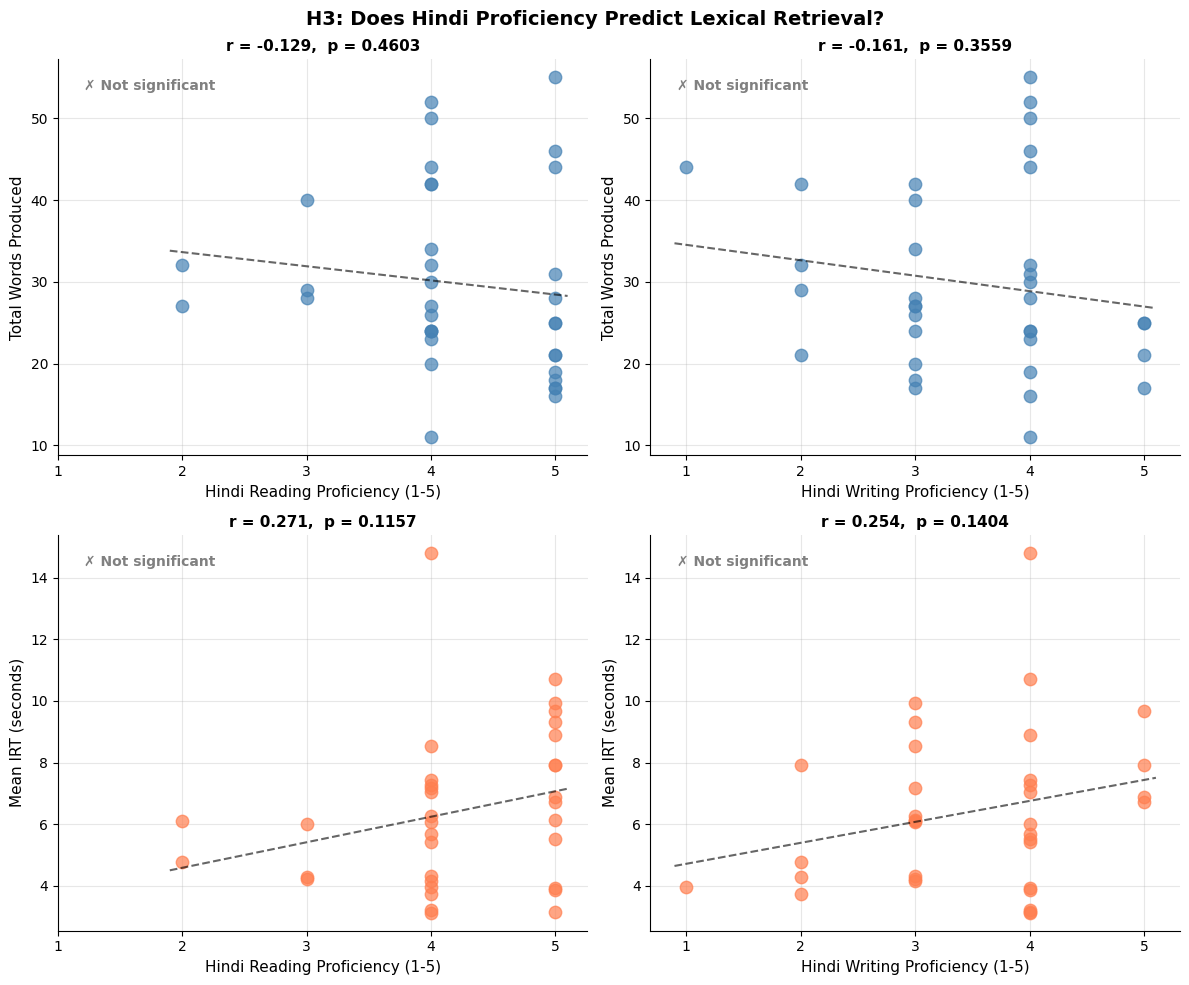


Saved as h3_scatter.png


In [19]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

# Collect one row per participant: Hi_Read, Hi_Write, total words, mean IRT
participant_data = []

for participant_id, participant in experiments.items():
    trials = participant['data']

    # Get proficiency scores
    hi_read  = None
    hi_write = None
    for trial in trials:
        if trial.get('typeoftrial') == 'insights':
            hi_read  = trial.get('Hi_Read')
            hi_write = trial.get('Hi_Write')
            break

    if hi_read is None or hi_write is None:
        continue

    # Get total words and mean IRT across all domains
    total_words = 0
    all_irts    = []

    for trial in trials:
        task   = trial.get('task')
        domain = trial.get('domain')

        if task != 'VFT':
            continue
        if domain == 'furniture-practice':
            continue

        words_raw = trial.get('tagged_responses', '[]')
        times_raw = trial.get('response_times',   '[]')
        words = [w['response'].strip() for w in json.loads(words_raw)]
        irts  = [t / 1000 for t in json.loads(times_raw)]

        total_words += len(words)
        all_irts.extend(irts)

    if not all_irts:
        continue

    participant_data.append({
        'id':          participant_id,
        'hi_read':     int(hi_read),
        'hi_write':    int(hi_write),
        'total_words': total_words,
        'mean_irt':    np.mean(all_irts)
    })

print(f"Participants with complete data: {len(participant_data)}")

# Extract arrays
hi_read     = np.array([p['hi_read']     for p in participant_data])
hi_write    = np.array([p['hi_write']    for p in participant_data])
total_words = np.array([p['total_words'] for p in participant_data])
mean_irts   = np.array([p['mean_irt']    for p in participant_data])

# Run correlations
bonferroni = 0.0042

print("=" * 60)
print("H3 TEST — Hindi proficiency vs retrieval performance")
print("=" * 60)

tests = [
    (hi_read,  total_words, 'Hi_Read',  'Total Words'),
    (hi_write, total_words, 'Hi_Write', 'Total Words'),
    (hi_read,  mean_irts,   'Hi_Read',  'Mean IRT'),
    (hi_write, mean_irts,   'Hi_Write', 'Mean IRT'),
]

for x, y, x_label, y_label in tests:
    r, p = stats.pearsonr(x, y)
    if p < bonferroni:
        sig = "✓ Significant (Bonferroni)"
    elif p < 0.05:
        sig = "~ Borderline (p<0.05)"
    else:
        sig = "✗ Not significant"
    print(f"  {x_label:10s} vs {y_label:12s} → r={r:6.3f}, p={p:.4f}  {sig}")

# Plot (kept concise; saved to file)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_configs = [
    (hi_read,  total_words, 'Hindi Reading Proficiency (1-5)', 'Total Words Produced', 'steelblue'),
    (hi_write, total_words, 'Hindi Writing Proficiency (1-5)', 'Total Words Produced', 'steelblue'),
    (hi_read,  mean_irts,   'Hindi Reading Proficiency (1-5)', 'Mean IRT (seconds)',   'coral'),
    (hi_write, mean_irts,   'Hindi Writing Proficiency (1-5)', 'Mean IRT (seconds)',   'coral'),
]

for ax, (x, y, x_label, y_label, color) in zip(axes.flatten(), plot_configs):
    ax.scatter(x, y, color=color, alpha=0.7, s=80, zorder=2)
    m, b   = np.polyfit(x, y, 1)
    x_line = np.linspace(min(x)-0.1, max(x)+0.1, 100)
    ax.plot(x_line, m*x_line + b, color='black', linewidth=1.5, linestyle='--', alpha=0.6)
    r, p = stats.pearsonr(x, y)
    if p < bonferroni:
        sig_text  = '✓ Significant'
        sig_color = 'green'
    elif p < 0.05:
        sig_text  = '~ Borderline'
        sig_color = 'orange'
    else:
        sig_text  = '✗ Not significant'
        sig_color = 'gray'
    ax.set_title(f'r = {r:.3f},  p = {p:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.text(0.05, 0.95, sig_text, transform=ax.transAxes, fontsize=10, color=sig_color, fontweight='bold', va='top')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('H3: Does Hindi Proficiency Predict Lexical Retrieval?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('h3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved as h3_scatter.png")


# Figures for slides

This cell indicates figures and plots intended for inclusion in presentation slides. The figures generated below are saved as PNG files for easy embedding in reports or slides.

In [20]:
# Slide summaries

import json
import numpy as np
from collections import Counter

with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

ages      = []
genders   = []
l1s       = []
hi_reads  = []
hi_writes = []

for participant_id, participant in experiments.items():
    trials = participant['data']

    for trial in trials:
        tt = trial.get('typeoftrial')

        #  Demographics 
        if tt == 'demographics':
            if trial.get('age'):
                ages.append(int(trial.get('age')))
            if trial.get('gender'):
                genders.append(trial.get('gender'))
            if trial.get('first_language'):
                l1s.append(trial.get('first_language').strip())

        #  Proficiency 
        if tt == 'insights':
            if trial.get('Hi_Read'):
                hi_reads.append(int(trial.get('Hi_Read')))
            if trial.get('Hi_Write'):
                hi_writes.append(int(trial.get('Hi_Write')))

#  Print summary for verification 
print("=" * 50)
print("PARTICIPANT SUMMARY — basic demographics and proficiency")
print("=" * 50)

print(f"\nTotal participants: {len(experiments)}")

print(f"\nAge:")
print(f"  Mean = {np.mean(ages):.1f}")
print(f"  SD   = {np.std(ages):.1f}")
print(f"  Min  = {min(ages)}, Max = {max(ages)}")

print(f"\nGender:")
for g, count in Counter(genders).items():
    print(f"  {g}: {count} ({100*count/len(genders):.0f}%)")

print(f"\nFirst Language (L1):")
for l, count in Counter(l1s).most_common():
    print(f"  {l}: {count} ({100*count/len(l1s):.0f}%)")

print(f"\nHindi Reading Proficiency:")
print(f"  Mean = {np.mean(hi_reads):.2f}")
print(f"  SD   = {np.std(hi_reads):.2f}")
print(f"  Distribution: {dict(Counter(hi_reads))}")

print(f"\nHindi Writing Proficiency:")
print(f"  Mean = {np.mean(hi_writes):.2f}")
print(f"  SD   = {np.std(hi_writes):.2f}")
print(f"  Distribution: {dict(Counter(hi_writes))}")


PARTICIPANT SUMMARY — basic demographics and proficiency

Total participants: 35

Age:
  Mean = 23.1
  SD   = 2.0
  Min  = 19, Max = 27

Gender:
  Male: 32 (91%)
  Female: 3 (9%)

First Language (L1):
  Hindi: 16 (46%)
  Gujarati: 5 (14%)
  English: 5 (14%)
  hindi: 4 (11%)
  Telugu: 2 (6%)
  Punjabi: 1 (3%)
  GUjarati: 1 (3%)
  Gujarti: 1 (3%)

Hindi Reading Proficiency:
  Mean = 4.20
  SD   = 0.82
  Distribution: {4: 16, 5: 14, 2: 2, 3: 3}

Hindi Writing Proficiency:
  Mean = 3.49
  SD   = 0.94
  Distribution: {4: 15, 5: 4, 3: 11, 1: 1, 2: 4}


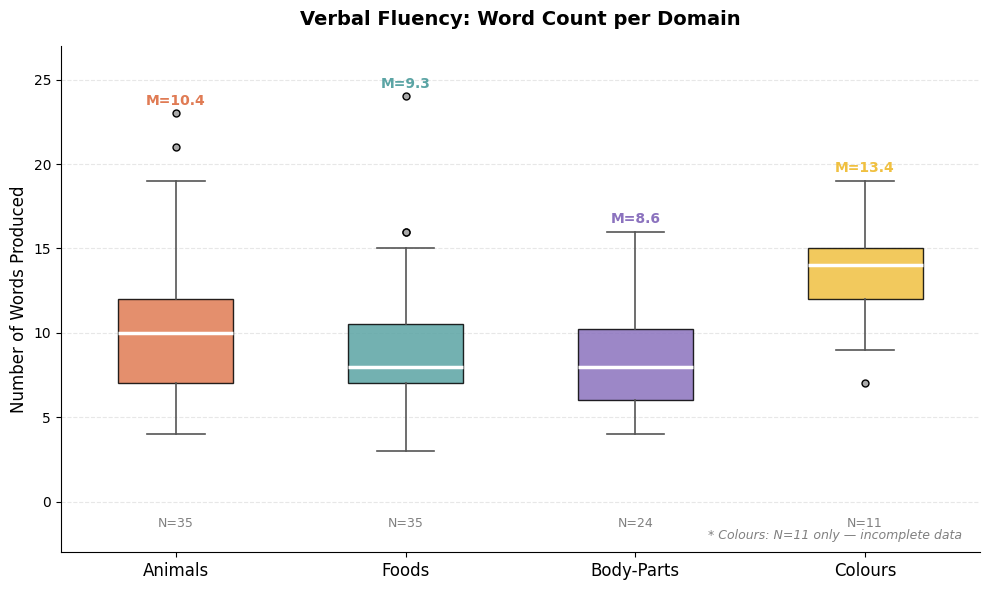

Saved as plot1_wordcount.png


In [21]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

# Collect word counts per domain
domain_counts = {'Animals': [], 'Foods': [], 'Body-Parts': [], 'Colours': []}
domain_map    = {'animals': 'Animals', 'foods': 'Foods', 'body-parts': 'Body-Parts', 'colours': 'Colours'}

for participant_id, participant in experiments.items():
    for trial in participant['data']:
        task   = trial.get('task')
        domain = trial.get('domain')
        if task != 'VFT' or domain not in domain_map:
            continue
        words = json.loads(trial.get('tagged_responses', '[]'))
        domain_counts[domain_map[domain]].append(len(words))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['#E07B54', '#5BA4A4', '#8B72BE', '#F0C040']
labels  = list(domain_counts.keys())
values  = list(domain_counts.values())

bp = ax.boxplot(values, patch_artist=True, widths=0.5, medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
for whisker in bp['whiskers']:
    whisker.set(color='#555', linewidth=1.2)
for cap in bp['caps']:
    cap.set(color='#555', linewidth=1.2)
for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='#aaa', markersize=5)

for i, vals in enumerate(values):
    mean = np.mean(vals)
    ax.text(i+1, max(vals) + 0.5, f'M={mean:.1f}', ha='center', fontsize=10, color=colors[i], fontweight='bold')
for i, vals in enumerate(values):
    ax.text(i+1, -1.5, f'N={len(vals)}', ha='center', fontsize=9, color='gray')

ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Number of Words Produced', fontsize=12)
ax.set_title('Verbal Fluency: Word Count per Domain', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(-3, max([max(v) for v in values]) + 3)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(0.98, 0.02, '* Colours: N=11 only — incomplete data', transform=ax.transAxes, fontsize=9, color='gray', style='italic', ha='right', va='bottom')

plt.tight_layout()
plt.savefig('plot1_wordcount.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as plot1_wordcount.png")


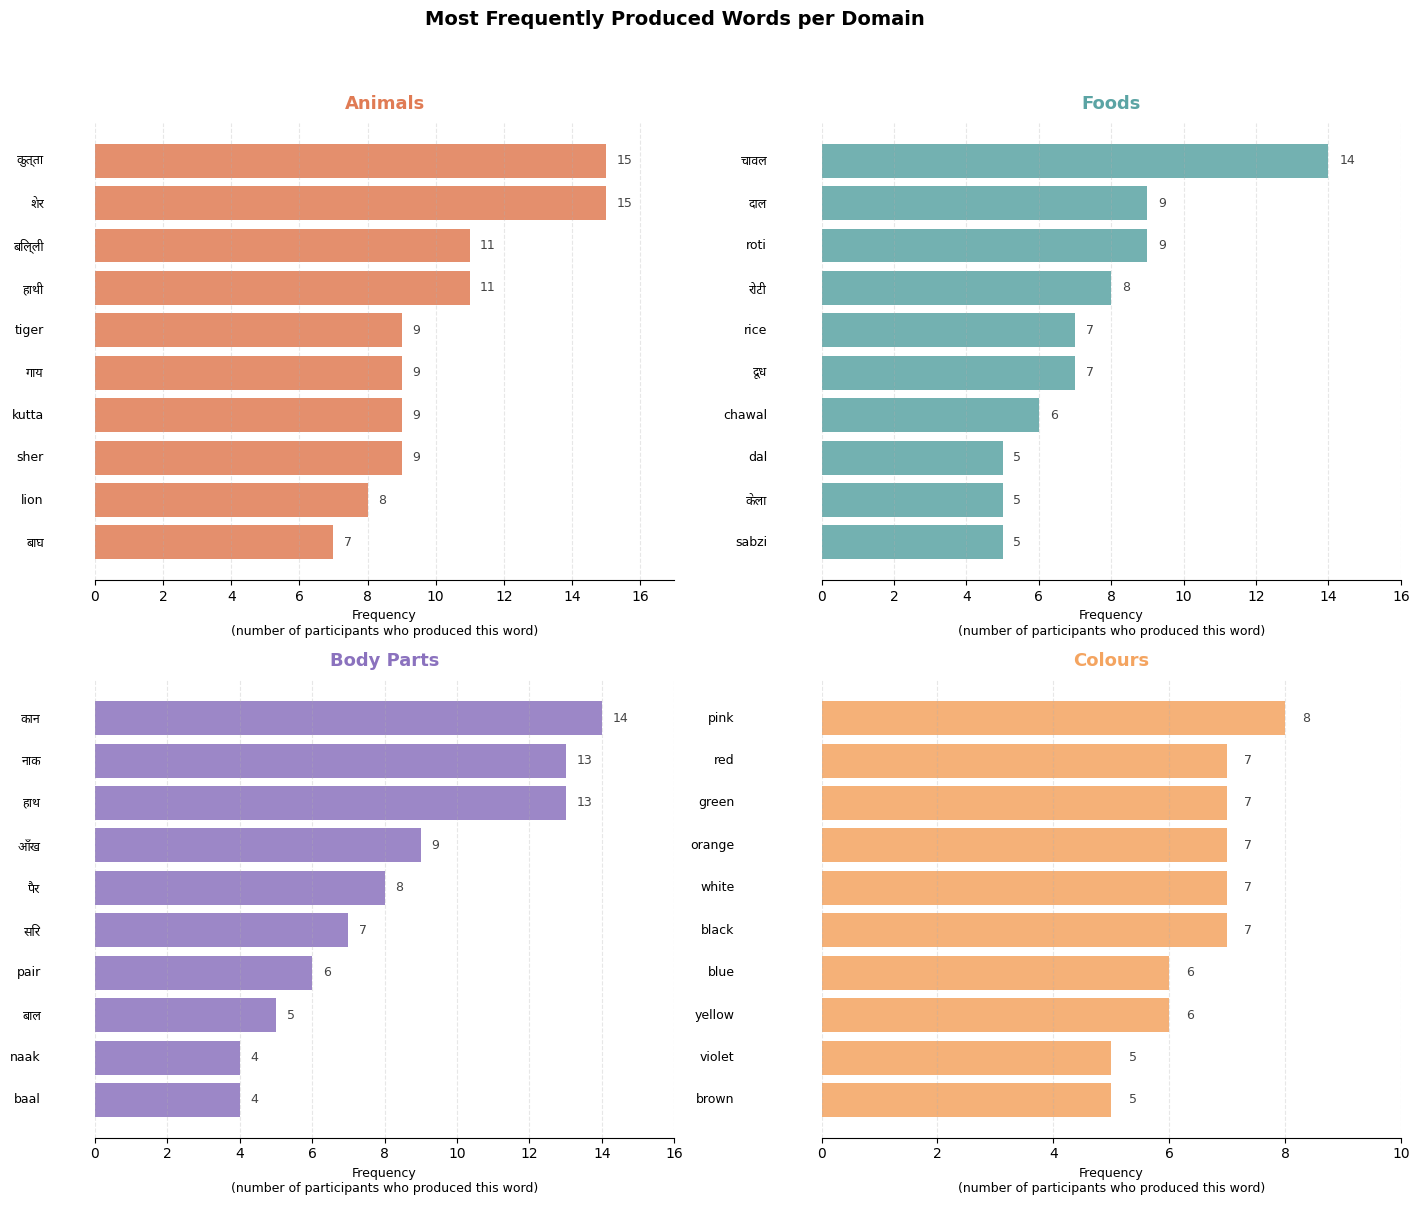

Saved as plot2_topwords.png


In [22]:
# Top-word frequency plots
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

domain_words = {'animals': [], 'foods': [], 'body-parts': [], 'colours': []}
for participant_id, participant in experiments.items():
    for trial in participant['data']:
        task   = trial.get('task')
        domain = trial.get('domain')
        if task != 'VFT' or domain not in domain_words:
            continue
        words = [w['response'].strip().lower() for w in json.loads(trial.get('tagged_responses', '[]'))]
        domain_words[domain].extend(words)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()
colors = {'animals': '#E07B54', 'foods': '#5BA4A4', 'body-parts': '#8B72BE', 'colours': '#F4A460'}
titles = {'animals': 'Animals', 'foods': 'Foods', 'body-parts': 'Body Parts', 'colours': 'Colours'}

for ax, domain in zip(axes, domain_words.keys()):
    top10  = Counter(domain_words[domain]).most_common(10)
    words  = [w for w, _ in top10]
    counts = [c for _, c in top10]
    bars = ax.barh(range(len(words)), counts, color=colors[domain], alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels([])
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False)
    for i, word in enumerate(words):
        if is_devanagari(word):
            ax.text(-1.5, i, word, fontproperties=hindi_font_small, ha='right', va='center', transform=ax.transData)
        else:
            ax.text(-1.5, i, word, fontsize=9, ha='right', va='center', transform=ax.transData)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=9, color='#444')
    ax.set_title(titles[domain], fontsize=13, fontweight='bold', color=colors[domain], pad=10)
    ax.set_xlabel('Frequency\n(number of participants who produced this word)', fontsize=9)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, max(counts) + 2)

fig.suptitle('Most Frequently Produced Words per Domain', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0.05, 0, 1, 0.97])
plt.savefig('plot2_topwords.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as plot2_topwords.png")


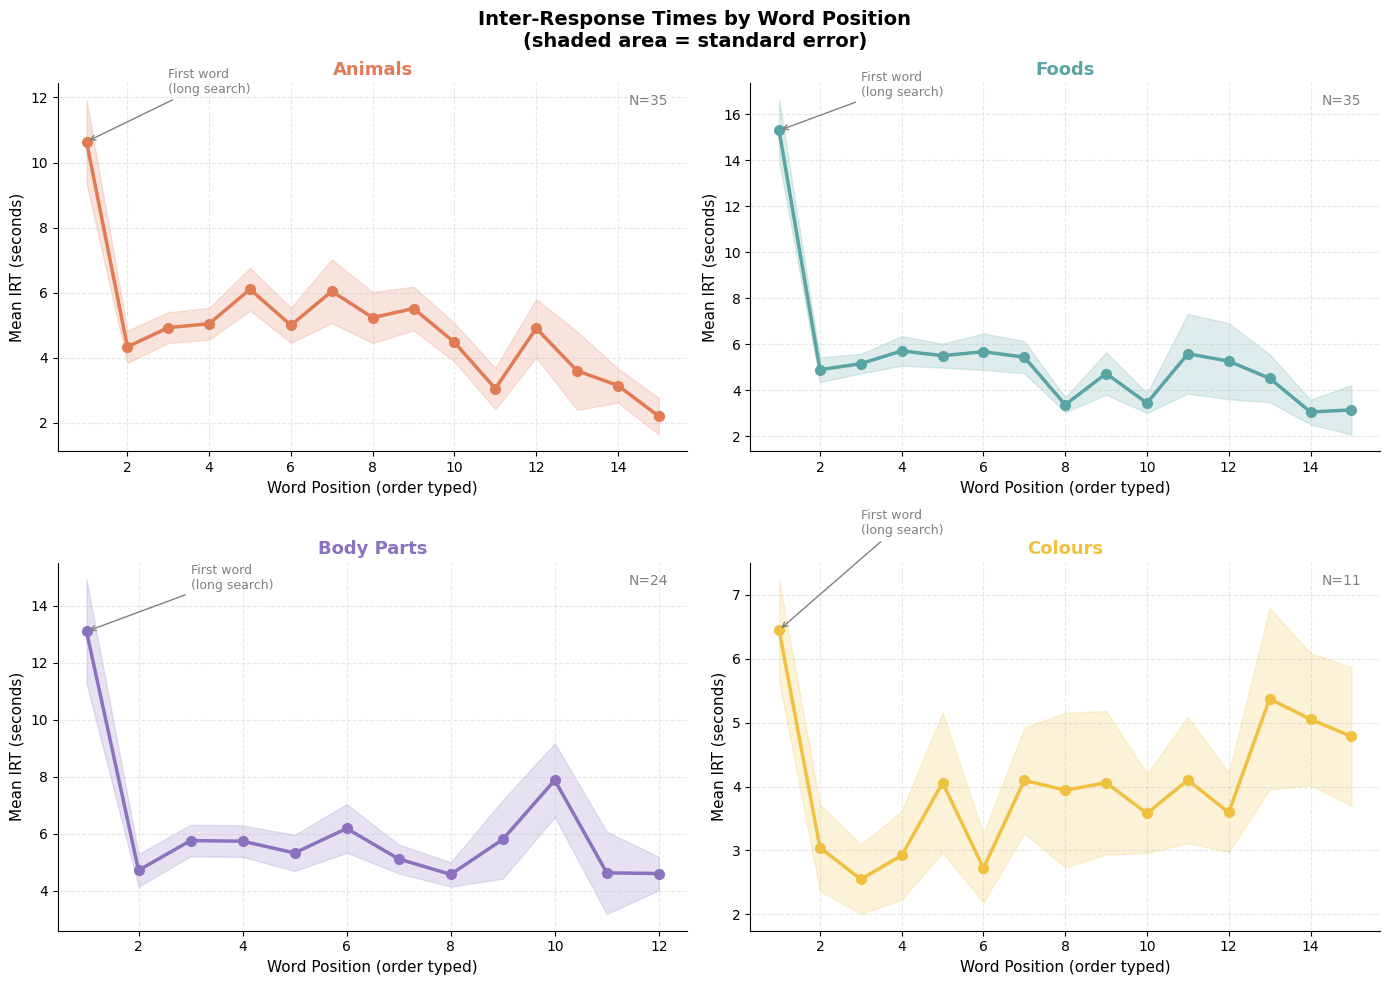

Saved as plot3_irt_position.png


In [23]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

domains = ['animals', 'foods', 'body-parts', 'colours']
colors  = {'animals': '#E07B54', 'foods': '#5BA4A4', 'body-parts': '#8B72BE', 'colours': '#F0C040'}
titles  = {'animals': 'Animals', 'foods': 'Foods', 'body-parts': 'Body Parts', 'colours': 'Colours'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, domain in enumerate(domains):
    max_position  = 15
    irts_by_pos   = [[] for _ in range(max_position)]
    for participant_id, participant in experiments.items():
        for trial in participant['data']:
            if trial.get('task') != 'VFT' or trial.get('domain') != domain:
                continue
            times_raw = trial.get('response_times', '[]')
            irts      = [t/1000 for t in json.loads(times_raw)]
            for pos, irt in enumerate(irts[:max_position]):
                irts_by_pos[pos].append(irt)

    positions = []
    means     = []
    sems      = []
    for pos in range(max_position):
        if len(irts_by_pos[pos]) < 3:
            continue
        positions.append(pos + 1)
        means.append(np.mean(irts_by_pos[pos]))
        sems.append(np.std(irts_by_pos[pos]) / np.sqrt(len(irts_by_pos[pos])))

    ax    = axes[idx]
    color = colors[domain]
    ax.plot(positions, means, 'o-', color=color, linewidth=2.5, markersize=7, zorder=2)
    ax.fill_between(positions, [m-s for m, s in zip(means, sems)], [m+s for m, s in zip(means, sems)], alpha=0.2, color=color)
    ax.annotate('First word\n(long search)', xy=(1, means[0]), xytext=(3, means[0] + 1.5), fontsize=9, color='gray', arrowprops=dict(arrowstyle='->', color='gray', lw=1))
    ax.set_xlabel('Word Position (order typed)', fontsize=11)
    ax.set_ylabel('Mean IRT (seconds)', fontsize=11)
    ax.set_title(f'{titles[domain]}', fontsize=13, fontweight='bold', color=color)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    n = sum(1 for p in experiments.values() for t in p['data'] if t.get('task') == 'VFT' and t.get('domain') == domain)
    ax.text(0.97, 0.97, f'N={n}', transform=ax.transAxes, ha='right', va='top', fontsize=10, color='gray')

fig.suptitle('Inter-Response Times by Word Position\n(shaded area = standard error)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_irt_position.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as plot3_irt_position.png")


In [24]:
# Dataframe-friendly extraction (VFT + SpAM rows)
PATH = "hindi.json"
with open(PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

experiments = data["fluency-spam"]

vft_rows = []
spam_rows = []

for session_id, session in experiments.items():
    subject_id = session.get("subject_id")
    trials = session.get("data", [])

    for tr in trials:
        task = tr.get("task")
        domain = tr.get("domain")

        # Skip non-task trials
        if task not in ("VFT", "SpAM"):
            continue

        # Skip practice trials if present
        if domain and "practice" in domain:
            continue

        if task == "VFT":
            tagged = safe_load_list(tr.get("tagged_responses"))
            rts = safe_load_list(tr.get("response_times"))
            n = min(len(tagged), len(rts))

            for i in range(n):
                word = str(tagged[i].get("response", "")).strip()
                vft_rows.append({
                    "session_id": session_id,
                    "subject_id": subject_id,
                    "domain": domain,
                    "word_index": i + 1,
                    "word": word,
                    "irt_ms": float(rts[i]) if rts[i] is not None else np.nan,
                })

        if task == "SpAM":
            dropped = tr.get("droppedwords", [])
            if not isinstance(dropped, list):
                dropped = []

            # Keep LAST position per word_id
            last_by_id = {}
            for d in dropped:
                wid = d.get("id")
                if wid is None:
                    continue
                last_by_id[wid] = d

            for wid, d in last_by_id.items():
                spam_rows.append({
                    "session_id": session_id,
                    "subject_id": subject_id,
                    "domain": domain,
                    "word_id": wid,
                    "word": str(d.get("word", "")).strip(),
                    "x": float(d.get("x_norm")) if d.get("x_norm") is not None else np.nan,
                    "y": float(d.get("y_norm")) if d.get("y_norm") is not None else np.nan,
                })

vft_df = pd.DataFrame(vft_rows).dropna(subset=["domain", "word", "irt_ms"])
spam_df = pd.DataFrame(spam_rows).dropna(subset=["domain", "word", "x", "y"])

print("VFT rows:", len(vft_df))
print("SpAM rows:", len(spam_df))
print("Domains in dataset:", sorted(vft_df["domain"].unique()))


VFT rows: 1044
SpAM rows: 1040
Domains in dataset: ['animals', 'body-parts', 'colours', 'foods']


In [25]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']
domains = ['animals', 'foods', 'body-parts', 'colours']

for domain in domains:
    all_first = []
    all_subsequent = []

    for participant in experiments.values():
        for trial in participant['data']:
            if trial.get('task') != 'VFT' or trial.get('domain') != domain:
                continue
            irts = [t/1000 for t in json.loads(trial.get('response_times', '[]'))]
            if not irts:
                continue
            all_first.append(irts[0])
            all_subsequent.extend(irts[1:])

    print(f"{domain:12s} | First={np.mean(all_first):.2f}s | Subsequent={np.mean(all_subsequent):.2f}s")


animals      | First=10.64s | Subsequent=4.85s
foods        | First=15.30s | Subsequent=4.94s
body-parts   | First=13.09s | Subsequent=5.46s
colours      | First=6.45s | Subsequent=3.72s


In [26]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']
domains = ['animals', 'foods', 'body-parts', 'colours']

for domain in domains:
    all_distances = []

    for participant in experiments.values():
        for trial in participant['data']:
            if trial.get('task') != 'SpAM' or trial.get('domain') != domain:
                continue

            dropped = trial.get('droppedwords', [])
            final   = {}
            for item in dropped:
                final[item['word']] = (item['x_norm'], item['y_norm'])

            coords = list(final.values())
            for i in range(len(coords)):
                for j in range(i+1, len(coords)):
                    x1, y1 = coords[i]
                    x2, y2 = coords[j]
                    dist = np.sqrt((x2-x1)**2 + (y2-y1)**2)
                    all_distances.append(dist)

    print(f"{domain:12s} | avg distance = {np.mean(all_distances):.3f}")


animals      | avg distance = 0.385
foods        | avg distance = 0.336
body-parts   | avg distance = 0.259
colours      | avg distance = 0.461


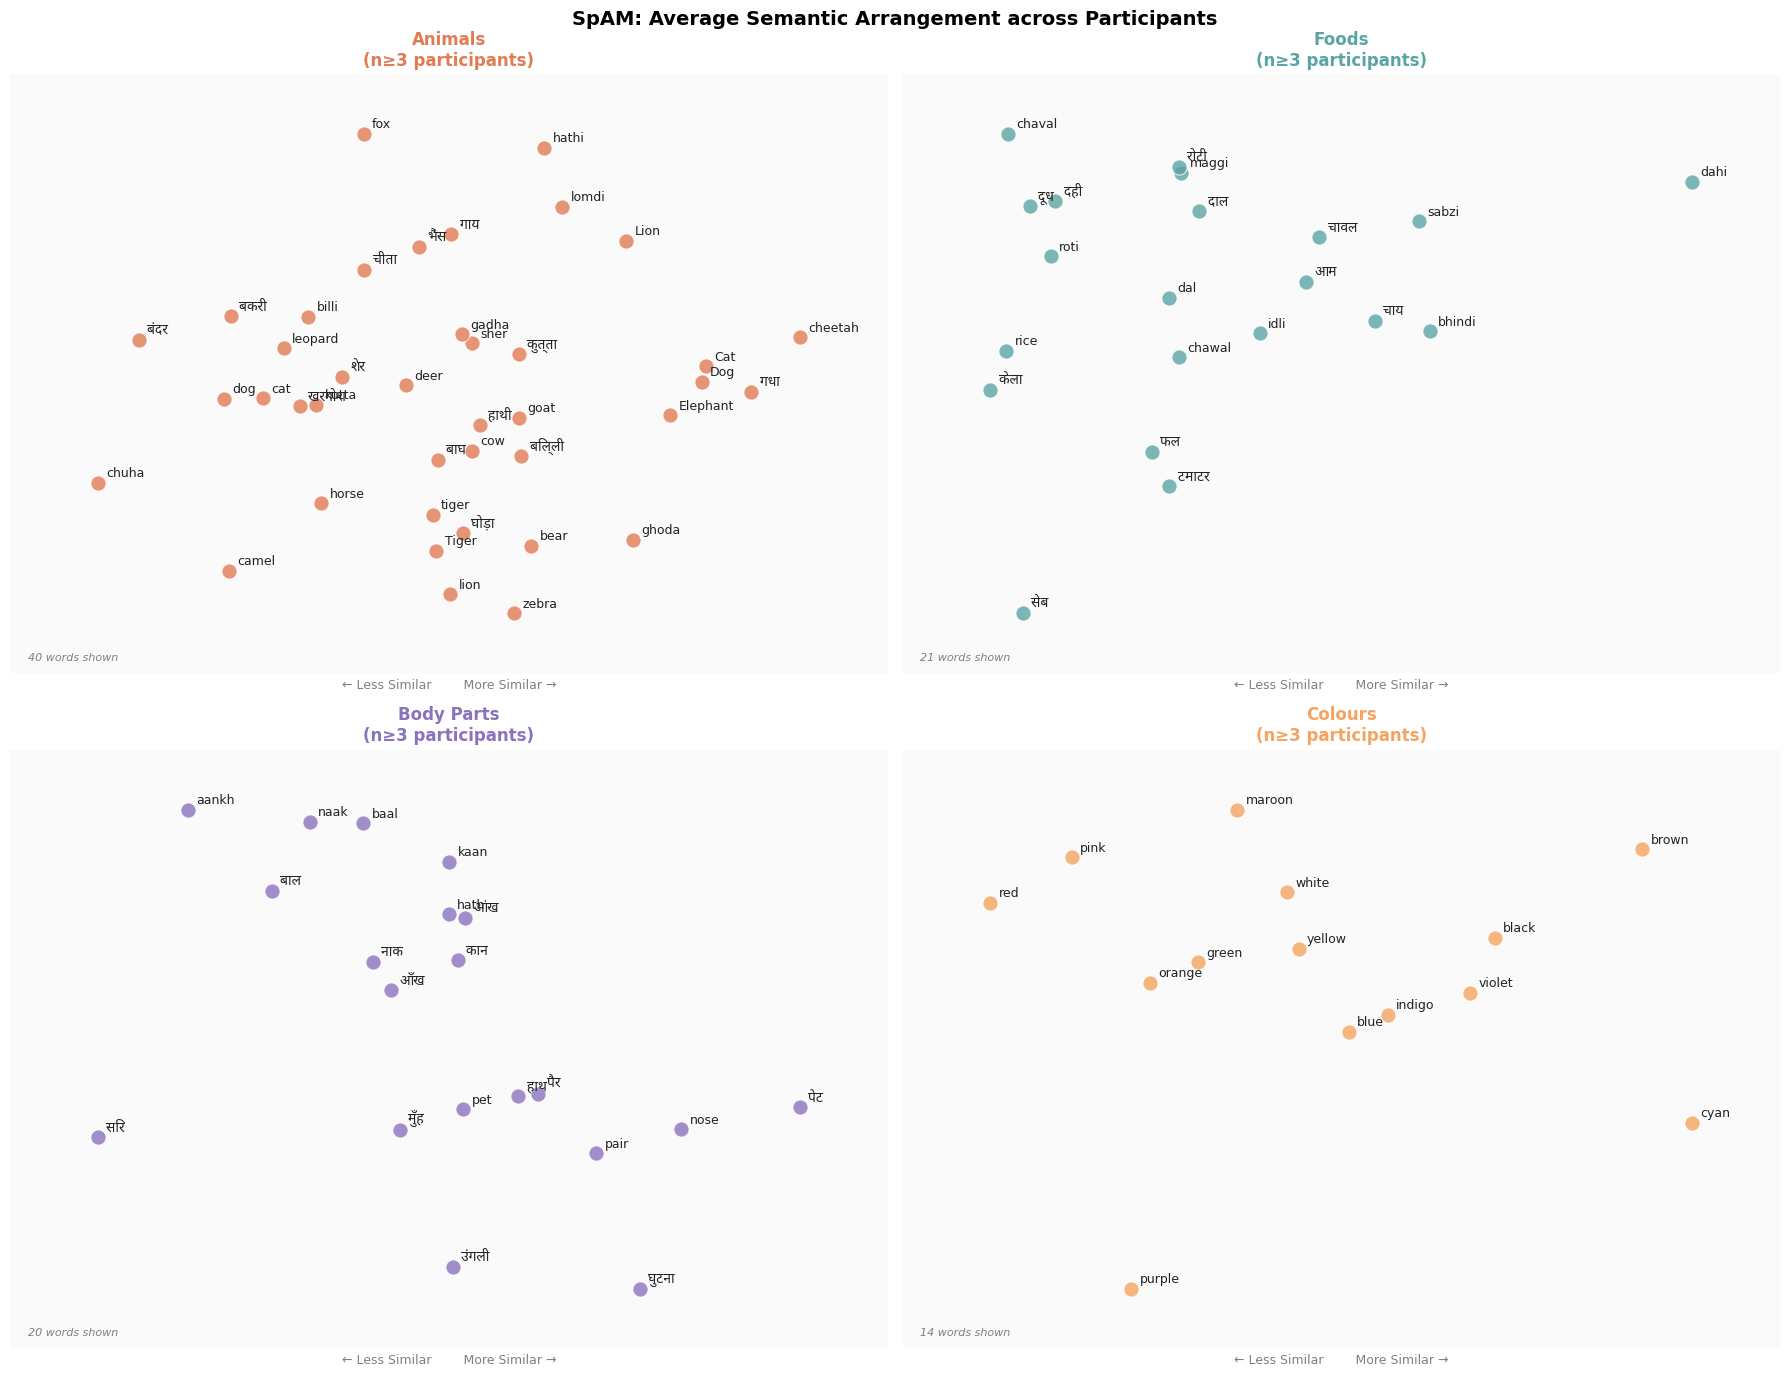

Saved!


In [27]:
# SpAM: average semantic arrangement plots (keep words seen by ≥3 participants)
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

domains = ['animals', 'foods', 'body-parts', 'colours']
colors  = {'animals': '#E07B54', 'foods': '#5BA4A4', 'body-parts': '#8B72BE', 'colours': '#F4A460'}
titles  = {'animals': 'Animals', 'foods': 'Foods', 'body-parts': 'Body Parts', 'colours': 'Colours'}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, domain in zip(axes, domains):
    word_positions = {}
    for participant in experiments.values():
        for trial in participant['data']:
            if trial.get('task') != 'SpAM' or trial.get('domain') != domain:
                continue
            dropped = trial.get('droppedwords', [])
            final   = {}
            for item in dropped:
                final[item['word']] = (item['x_norm'], item['y_norm'])
            for word, pos in final.items():
                word_positions.setdefault(word, []).append(pos)

    common = {w: v for w, v in word_positions.items() if len(v) >= 3}
    words = list(common.keys())
    avg_x = [np.mean([p[0] for p in common[w]]) for w in words]
    avg_y = [1 - np.mean([p[1] for p in common[w]]) for w in words]

    if avg_x and avg_y:
        min_x, max_x = min(avg_x), max(avg_x)
        min_y, max_y = min(avg_y), max(avg_y)
        avg_x = [(x-min_x)/(max_x-min_x)*0.8+0.1 if max_x != min_x else 0.5 for x in avg_x]
        avg_y = [(y-min_y)/(max_y-min_y)*0.8+0.1 if max_y != min_y else 0.5 for y in avg_y]

    for x, y, word in zip(avg_x, avg_y, words):
        font = hindi_font if is_devanagari(word) else None
        if font is not None:
            ax.annotate(word, xy=(x, y), xytext=(6, 4), textcoords='offset points', fontproperties=font, color='#222')
        else:
            ax.annotate(word, xy=(x, y), xytext=(6, 4), textcoords='offset points', fontsize=9, color='#222')

    ax.scatter(avg_x, avg_y, s=120, color=colors[domain], alpha=0.8, zorder=2, edgecolors='white', linewidth=0.8)
    ax.set_title(f'{titles[domain]}\n(n≥3 participants)', fontsize=12, fontweight='bold', color=colors[domain])
    ax.set_xlabel('← Less Similar        More Similar →', fontsize=9, color='gray')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.set_facecolor('#FAFAFA')
    ax.text(0.02, 0.02, f'{len(words)} words shown', transform=ax.transAxes, fontsize=8, color='gray', style='italic')

fig.suptitle('SpAM: Average Semantic Arrangement across Participants', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('plot4_spam_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")


In [28]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

# Inspect demographics/insights for first participant
first_id          = list(experiments.keys())[0]
first_participant = experiments[first_id]

print("Trials with type = demographics or insights:\n")
for trial in first_participant['data']:
    tt = trial.get('typeoftrial')
    if tt in ('demographics', 'insights'):
        print(f"Type: {tt}")
        print(f"Keys available: {list(trial.keys())}")
        print(f"Selected content preview: {{k: trial.get(k) for k in list(trial.keys()) if k in ('age','gender','first_language','Hi_Read','Hi_Write')}}")
        print("-" * 60)


Trials with type = demographics or insights:

Type: insights
Keys available: ['rt', 'response', 'typeoftrial', 'trial_type', 'trial_index', 'time_elapsed', 'internal_node_id', 'subject', 'strategies', 'Hi_Read', 'Hi_Write', 'En_Read', 'En_Write']
Selected content preview: {k: trial.get(k) for k in list(trial.keys()) if k in ('age','gender','first_language','Hi_Read','Hi_Write')}
------------------------------------------------------------
Type: demographics
Keys available: ['rt', 'response', 'typeoftrial', 'trial_type', 'trial_index', 'time_elapsed', 'internal_node_id', 'subject', 'first_language', 'language_count', 'languages_list']
Selected content preview: {k: trial.get(k) for k in list(trial.keys()) if k in ('age','gender','first_language','Hi_Read','Hi_Write')}
------------------------------------------------------------
Type: demographics
Keys available: ['rt', 'response', 'typeoftrial', 'trial_type', 'trial_index', 'time_elapsed', 'internal_node_id', 'subject', 'language_confide

# Supplementary analyses

Additional analyses addressing follow-up questions are included in the cells below. These are intended as supplementary material for the report.

In [29]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

irts_by_pos = {}

for participant in experiments.values():
    for trial in participant['data']:
        if trial.get('task') != 'VFT' or trial.get('domain') != 'animals':
            continue
        irts = [t/1000 for t in json.loads(trial.get('response_times', '[]'))]
        for pos, irt in enumerate(irts):
            irts_by_pos.setdefault(pos, []).append(irt)

# Print mean IRT at each position
print("Position | Mean IRT | N participants")
print("-" * 40)
for pos in sorted(irts_by_pos.keys()):
    vals = irts_by_pos[pos]
    if len(vals) < 5:
        continue
    print(f"  {pos+1:5d}  |  {np.mean(vals):.2f}s   | {len(vals)}")


Position | Mean IRT | N participants
----------------------------------------
      1  |  10.64s   | 35
      2  |  4.34s   | 35
      3  |  4.93s   | 35
      4  |  5.05s   | 35
      5  |  6.11s   | 33
      6  |  5.00s   | 32
      7  |  6.04s   | 29
      8  |  5.24s   | 25
      9  |  5.52s   | 23
     10  |  4.48s   | 19
     11  |  3.05s   | 11
     12  |  4.91s   | 10
     13  |  3.60s   | 8
     14  |  3.15s   | 6
     15  |  2.20s   | 6
     16  |  2.87s   | 6
     17  |  5.10s   | 5


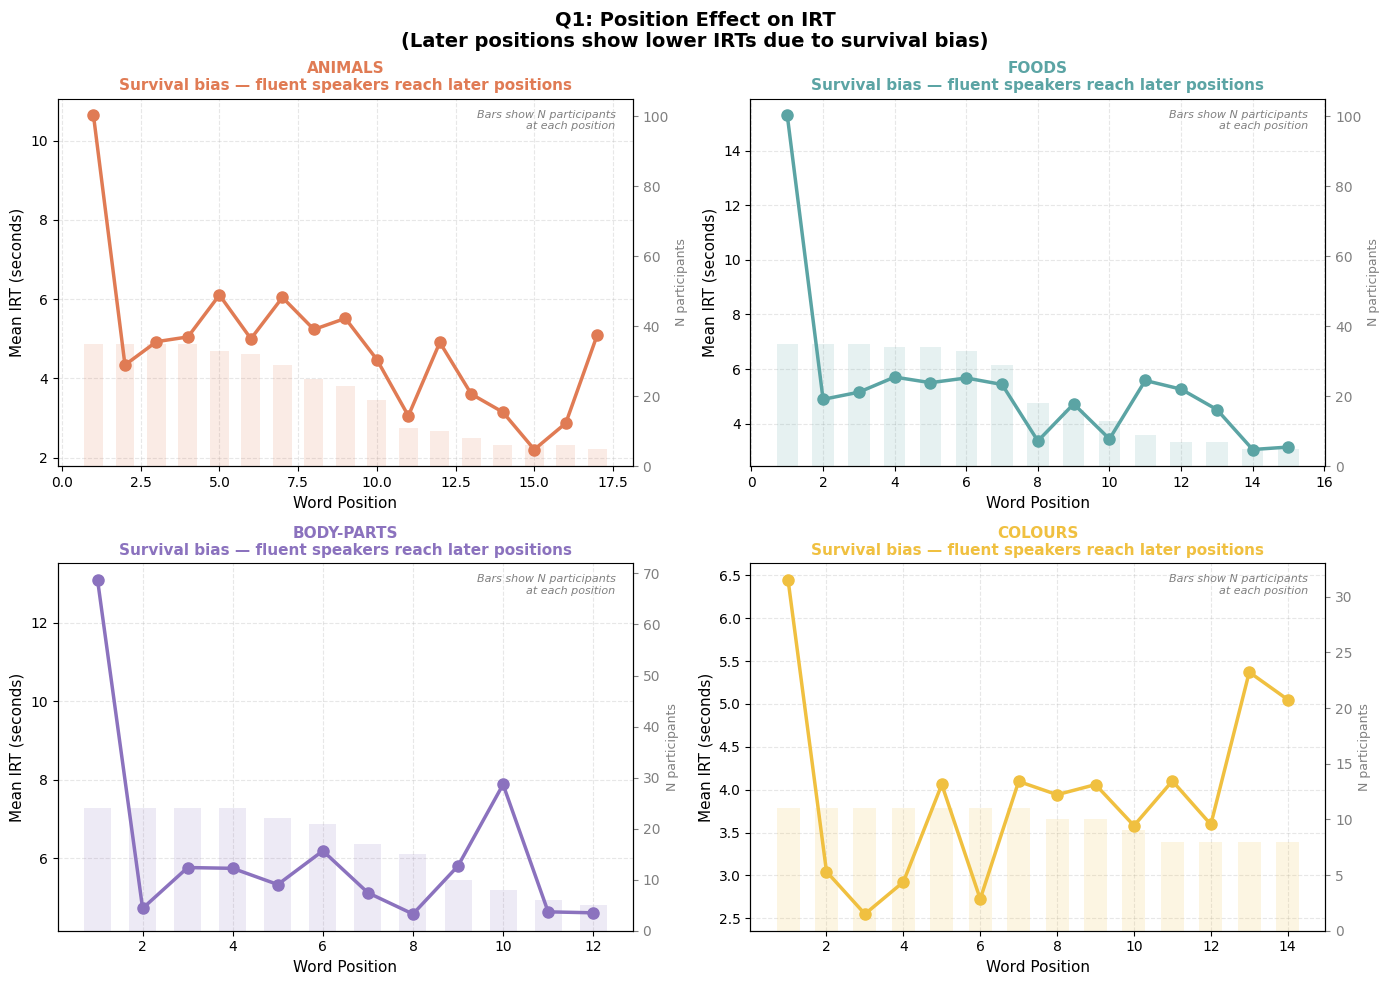

Saved as q1_position_effect.png


In [30]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']
domains = ['animals', 'foods', 'body-parts', 'colours']
colors  = {'animals': '#E07B54', 'foods': '#5BA4A4', 'body-parts': '#8B72BE', 'colours': '#F0C040'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, domain in enumerate(domains):
    irts_by_pos = {}
    for participant in experiments.values():
        for trial in participant['data']:
            if trial.get('task') != 'VFT' or trial.get('domain') != domain:
                continue
            irts = [t/1000 for t in json.loads(trial.get('response_times', '[]'))]
            for pos, irt in enumerate(irts):
                irts_by_pos.setdefault(pos, []).append(irt)

    positions = []
    means     = []
    ns        = []
    for pos in sorted(irts_by_pos.keys()):
        vals = irts_by_pos[pos]
        if len(vals) < 5:
            continue
        positions.append(pos + 1)
        means.append(np.mean(vals))
        ns.append(len(vals))

    ax    = axes[idx]
    color = colors[domain]
    ax.plot(positions, means, 'o-', color=color, linewidth=2.5, markersize=8, zorder=2)
    ax2 = ax.twinx()
    ax2.bar(positions, ns, color=color, alpha=0.15, width=0.6, zorder=1)
    ax2.set_ylabel('N participants', fontsize=9, color='gray')
    ax2.tick_params(axis='y', colors='gray')
    ax2.set_ylim(0, max(ns) * 3 if ns else 1)
    ax.text(0.97, 0.97, 'Bars show N participants\nat each position', transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray', style='italic')
    ax.set_xlabel('Word Position', fontsize=11)
    ax.set_ylabel('Mean IRT (seconds)', fontsize=11)
    ax.set_title(f'{domain.upper()}\nSurvival bias — fluent speakers reach later positions', fontsize=11, fontweight='bold', color=color)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)

fig.suptitle('Q1: Position Effect on IRT\n(Later positions show lower IRTs due to survival bias)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('q1_position_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as q1_position_effect.png")


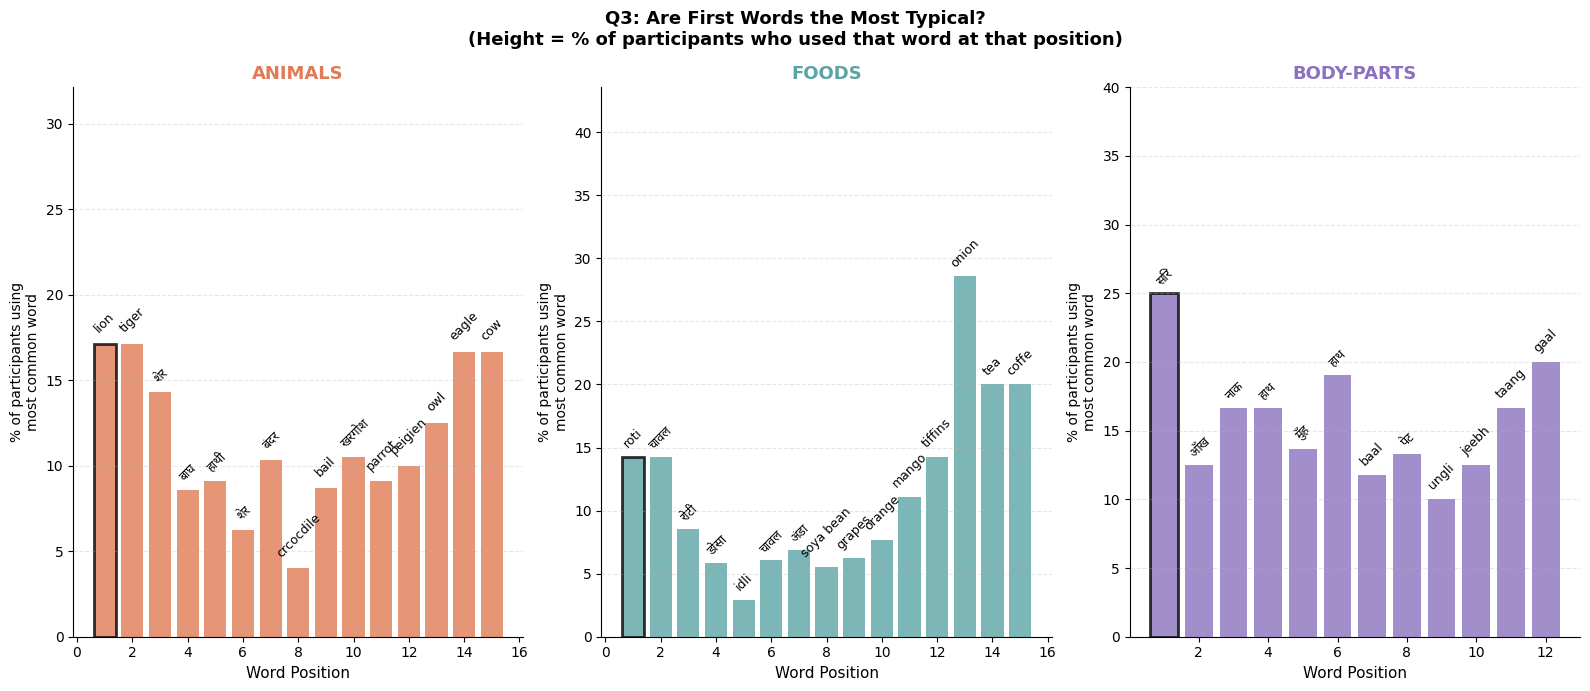

Saved as q3_first_words.png


In [31]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']
domains = ['animals', 'foods', 'body-parts']
colors  = {'animals': '#E07B54', 'foods': '#5BA4A4', 'body-parts': '#8B72BE'}

fig, axes = plt.subplots(1, 3, figsize=(16, 7))

for ax, domain in zip(axes, domains):
    position_words = {}
    for participant in experiments.values():
        for trial in participant['data']:
            if trial.get('task') != 'VFT' or trial.get('domain') != domain:
                continue
            words = [w['response'].strip().lower() for w in json.loads(trial.get('tagged_responses', '[]'))]
            for pos, word in enumerate(words):
                position_words.setdefault(pos, []).append(word)

    positions  = []
    top_words  = []
    top_counts = []
    total_ns   = []

    for pos in range(15):
        if pos not in position_words:
            break
        words_at_pos = position_words[pos]
        if len(words_at_pos) < 5:
            break
        most_common_word, count = Counter(words_at_pos).most_common(1)[0]
        positions.append(pos + 1)
        top_words.append(most_common_word)
        top_counts.append(count)
        total_ns.append(len(words_at_pos))

    percentages = [c/n*100 for c, n in zip(top_counts, total_ns)]
    bars = ax.bar(positions, percentages, color=colors[domain], alpha=0.8)

    def is_dev(word):
        return any('\u0900' <= c <= '\u097F' for c in word)

    for pos, word, pct in zip(positions, top_words, percentages):
        font = hindi_font if is_dev(word) else None
        if font is not None:
            ax.text(pos, pct + 0.5, word, ha='center', va='bottom', fontproperties=font, fontsize=9, rotation=45)
        else:
            ax.text(pos, pct + 0.5, word, ha='center', va='bottom', fontsize=9, rotation=45)

    bars[0].set_edgecolor('black')
    bars[0].set_linewidth(2)
    ax.set_xlabel('Word Position', fontsize=11)
    ax.set_ylabel('% of participants using\nmost common word', fontsize=10)
    ax.set_title(f'{domain.upper()}', fontsize=13, fontweight='bold', color=colors[domain])
    ax.set_ylim(0, max(percentages) + 15 if percentages else 100)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Q3: Are First Words the Most Typical?\n(Height = % of participants who used that word at that position)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q3_first_words.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as q3_first_words.png")


In [32]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']
domains = ['animals', 'foods', 'body-parts']

print("Most common FIRST word per domain:\n")
print("=" * 55)

for domain in domains:
    first_words = []

    for participant in experiments.values():
        for trial in participant['data']:
            if trial.get('task') != 'VFT' or trial.get('domain') != domain:
                continue
            words = [w['response'].strip().lower() for w in json.loads(trial.get('tagged_responses', '[]'))]
            if words:
                first_words.append(words[0])

    top5 = Counter(first_words).most_common(5)
    total = len(first_words)

    print(f"\nDomain: {domain.upper()} (N={total})")
    print(f"{'Word':15s} | {'Count':6s} | {'% of participants'}")
    print("-" * 45)
    for word, count in top5:
        pct = count/total*100 if total else 0
        print(f"{word:15s} | {count:6d} | {pct:.1f}%")


Most common FIRST word per domain:


Domain: ANIMALS (N=35)
Word            | Count  | % of participants
---------------------------------------------
lion            |      6 | 17.1%
कुत्ता          |      6 | 17.1%
गाय             |      6 | 17.1%
kutta           |      6 | 17.1%
शेर             |      5 | 14.3%

Domain: FOODS (N=35)
Word            | Count  | % of participants
---------------------------------------------
roti            |      5 | 14.3%
चावल            |      5 | 14.3%
दाल             |      3 | 8.6%
rice            |      3 | 8.6%
lays            |      1 | 2.9%

Domain: BODY-PARTS (N=24)
Word            | Count  | % of participants
---------------------------------------------
सिर             |      6 | 25.0%
कान             |      3 | 12.5%
आँख             |      3 | 12.5%
आंख             |      2 | 8.3%
hath            |      2 | 8.3%


# Language count analysis

This section examines whether the number of languages a participant knows is associated with Hindi retrieval performance (total words produced and mean IRT). Results are reported as correlations and summary tables.

In [33]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

# Collect per participant: language count + total words
participant_stats = []
for participant in experiments.values():
    trials = participant['data']
    lang_count   = None
    lang_list    = None
    hi_confidence = None
    total_words  = 0
    mean_irt_val = []

    for trial in trials:
        tt = trial.get('typeoftrial')
        if tt == 'demographics':
            if trial.get('language_count'):
                lang_count = int(trial.get('language_count'))
            if trial.get('languages_list'):
                lang_list = trial.get('languages_list')
            if trial.get('language_confidence'):
                conf = trial.get('language_confidence')
                if 'Hindi' in conf:
                    hi_confidence = int(conf['Hindi'])
        if trial.get('task') == 'VFT':
            domain = trial.get('domain')
            if domain == 'furniture-practice':
                continue
            words = json.loads(trial.get('tagged_responses', '[]'))
            irts  = [t/1000 for t in json.loads(trial.get('response_times', '[]'))]
            total_words += len(words)
            mean_irt_val.extend(irts)

    if lang_count is None or not mean_irt_val:
        continue

    participant_stats.append({
        'lang_count':    lang_count,
        'hi_confidence': hi_confidence,
        'total_words':   total_words,
        'mean_irt':      np.mean(mean_irt_val),
        'lang_list':     lang_list
    })

print("Language count distribution:\n")
from collections import Counter
lc = Counter(p['lang_count'] for p in participant_stats)
for count, freq in sorted(lc.items()):
    words_mean = np.mean([p['total_words'] for p in participant_stats if p['lang_count'] == count])
    irt_mean   = np.mean([p['mean_irt'] for p in participant_stats if p['lang_count'] == count])
    print(f"  {count} languages → {freq:2d} participants | Mean words = {words_mean:.1f} | Mean IRT = {irt_mean:.2f}s")

# Correlations
lang_counts = np.array([p['lang_count']  for p in participant_stats])
total_words = np.array([p['total_words'] for p in participant_stats])
mean_irts   = np.array([p['mean_irt']    for p in participant_stats])

r_words, p_words = stats.pearsonr(lang_counts, total_words)
r_irt,   p_irt   = stats.pearsonr(lang_counts, mean_irts)

print(f"\nCorrelation — language count vs total words: r={r_words:.3f}, p={p_words:.4f}")
print(f"Correlation — language count vs mean IRT:   r={r_irt:.3f}, p={p_irt:.4f}")


Language count distribution:

  2 languages → 14 participants | Mean words = 34.0 | Mean IRT = 5.46s
  3 languages → 17 participants | Mean words = 25.9 | Mean IRT = 7.27s
  4 languages →  2 participants | Mean words = 42.0 | Mean IRT = 4.08s
  5 languages →  1 participants | Mean words = 18.0 | Mean IRT = 9.31s
  9 languages →  1 participants | Mean words = 25.0 | Mean IRT = 6.73s

Correlation — language count vs total words: r=-0.179, p=0.3046
Correlation — language count vs mean IRT:   r=0.147, p=0.3985


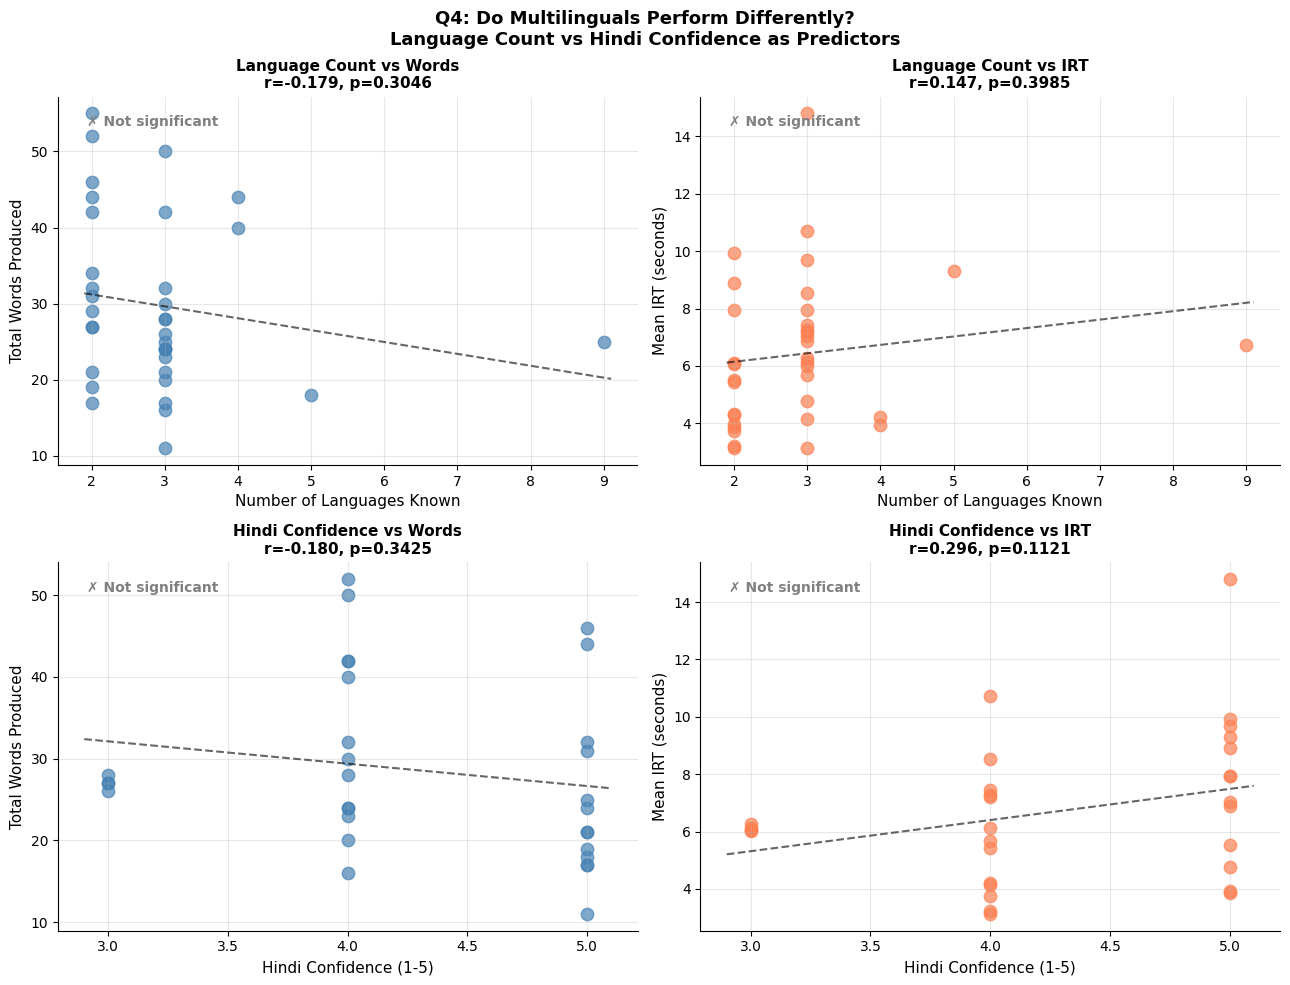

Saved as q4_multilingual.png


In [34]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

participant_stats = []
for participant in experiments.values():
    trials = participant['data']
    lang_count    = None
    hi_confidence = None
    total_words   = 0
    mean_irt_val  = []

    for trial in trials:
        tt = trial.get('typeoftrial')
        if tt == 'demographics':
            if trial.get('language_count'):
                lang_count = int(trial.get('language_count'))
            if trial.get('language_confidence'):
                conf = trial.get('language_confidence')
                if 'Hindi' in conf:
                    hi_confidence = int(conf['Hindi'])
        if trial.get('task') == 'VFT':
            if trial.get('domain') == 'furniture-practice':
                continue
            words = json.loads(trial.get('tagged_responses', '[]'))
            irts  = [t/1000 for t in json.loads(trial.get('response_times', '[]'))]
            total_words += len(words)
            mean_irt_val.extend(irts)

    if lang_count is None or not mean_irt_val:
        continue

    participant_stats.append({
        'lang_count':    lang_count,
        'hi_confidence': hi_confidence,
        'total_words':   total_words,
        'mean_irt':      np.mean(mean_irt_val)
    })

lang_counts   = np.array([p['lang_count']    for p in participant_stats])
hi_conf       = np.array([p['hi_confidence'] for p in participant_stats if p['hi_confidence'] is not None])
total_words_lc = np.array([p['total_words']  for p in participant_stats])
mean_irts_lc   = np.array([p['mean_irt']     for p in participant_stats])
total_words_hc = np.array([p['total_words']  for p in participant_stats if p['hi_confidence'] is not None])
mean_irts_hc   = np.array([p['mean_irt']     for p in participant_stats if p['hi_confidence'] is not None])

# Plot
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
plot_configs = [
    (lang_counts,  total_words_lc, 'Number of Languages Known', 'Total Words Produced', 'steelblue',  'Language Count vs Words'),
    (lang_counts,  mean_irts_lc,   'Number of Languages Known', 'Mean IRT (seconds)',   'coral',      'Language Count vs IRT'),
    (hi_conf,      total_words_hc, 'Hindi Confidence (1-5)', 'Total Words Produced', 'steelblue',  'Hindi Confidence vs Words'),
    (hi_conf,      mean_irts_hc,   'Hindi Confidence (1-5)', 'Mean IRT (seconds)',   'coral',      'Hindi Confidence vs IRT'),
]

for ax, (x, y, x_label, y_label, color, title) in zip(axes.flatten(), plot_configs):
    ax.scatter(x, y, color=color, alpha=0.7, s=80)
    r, p = stats.pearsonr(x, y)
    m, b   = np.polyfit(x, y, 1)
    x_line = np.linspace(min(x)-0.1, max(x)+0.1, 100)
    ax.plot(x_line, m*x_line+b, color='black', linewidth=1.5, linestyle='--', alpha=0.6)
    if p < 0.0042:
        sig_text  = '✓ Significant (Bonferroni)'
        sig_color = 'green'
    elif p < 0.05:
        sig_text  = '~ Borderline (p<0.05)'
        sig_color = 'orange'
    else:
        sig_text  = '✗ Not significant'
        sig_color = 'gray'
    ax.set_title(f'{title}\nr={r:.3f}, p={p:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.text(0.05, 0.95, sig_text, transform=ax.transAxes, fontsize=10, color=sig_color, fontweight='bold', va='top')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Q4: Do Multilinguals Perform Differently?\nLanguage Count vs Hindi Confidence as Predictors', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q4_multilingual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as q4_multilingual.png")


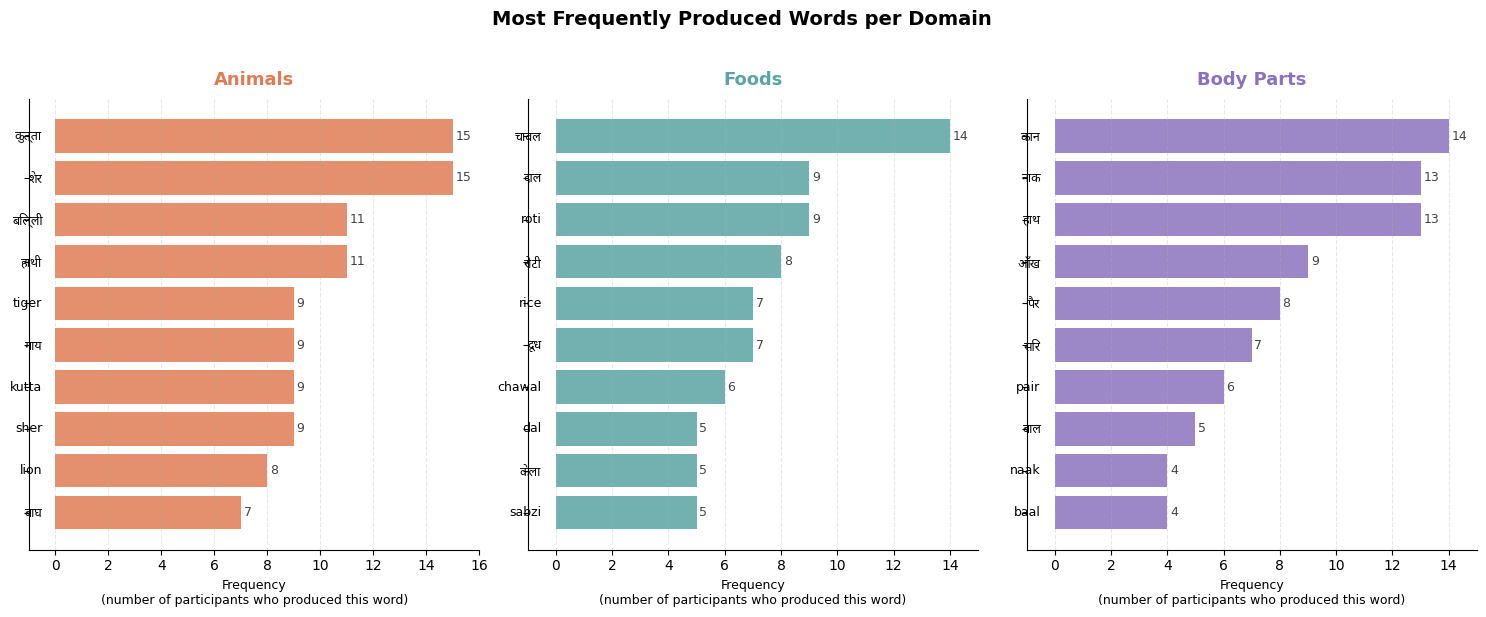

Saved as plot2_topwords.png


In [35]:
with open('hindi.json') as f:
    data = json.load(f)

experiments = data['fluency-spam']

domain_words = {'animals': [], 'foods': [], 'body-parts': []}
for participant_id, participant in experiments.items():
    for trial in participant['data']:
        task   = trial.get('task')
        domain = trial.get('domain')
        if task != 'VFT' or domain not in domain_words:
            continue
        words = [w['response'].strip().lower() for w in json.loads(trial.get('tagged_responses', '[]'))]
        domain_words[domain].extend(words)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
colors = {'animals': '#E07B54', 'foods': '#5BA4A4', 'body-parts': '#8B72BE'}
titles = {'animals': 'Animals', 'foods': 'Foods', 'body-parts': 'Body Parts'}

for ax, domain in zip(axes, domain_words.keys()):
    top10  = Counter(domain_words[domain]).most_common(10)
    words  = [w for w, _ in top10]
    counts = [c for _, c in top10]
    bars = ax.barh(range(len(words)), counts, color=colors[domain], alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels([])
    for i, word in enumerate(words):
        font = hindi_font_small if is_devanagari(word) else None
        if font is not None:
            ax.text(-0.5, i, word, fontproperties=font, ha='right', va='center')
        else:
            ax.text(-0.5, i, word, fontsize=9, ha='right', va='center')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=9, color='#444')
    ax.set_title(titles[domain], fontsize=13, fontweight='bold', color=colors[domain], pad=10)
    ax.set_xlabel('Frequency\n(number of participants who produced this word)', fontsize=9)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(-1, max(counts) + 1)

fig.suptitle('Most Frequently Produced Words per Domain', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot2_topwords.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as plot2_topwords.png")
